In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import matplotlib as mpl
import pandas as pd
#import cartopy.crs as ccrs
import os
import datetime
from datetime import timedelta
from matplotlib import ticker
from matplotlib.axes import Axes
import matplotlib
#from cartopy.mpl.geoaxes import GeoAxes
#import cartopy.feature as cfeature
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from scipy import stats
import scipy
import matplotlib.dates as mdates
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker, VPacker
#import shapefile as shp
import matplotlib.patches as patches
#from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

#GeoAxes._pcolormesh_patched = Axes.pcolormesh

In [2]:
def weekly_sum(data):
    
    weekly_list = []
    
    for year in np.unique(data["time.year"]):
        start = pd.Timestamp(f"{year}-01-01")
        end = pd.Timestamp(f"{year}-12-31")
    
        da_year = data.sel(time=slice(start, end))
    
        # Define 7-day bins starting Jan 1, ending Dec 31
        bin_edges = pd.date_range(start, end + pd.Timedelta(days=7), freq="7D")
    
        # Group days into those bins
        weekly_year = da_year.groupby_bins("time", bins=bin_edges, right=False).sum()
    
        # Rename the resulting coordinate so we can use it as "time"
        weekly_year = weekly_year.rename({"time_bins": "time"})
    
        # Set the coordinate values to the left bin edges (start of week)
        weekly_year = weekly_year.assign_coords(time=bin_edges[:-1])
    
        weekly_list.append(weekly_year)
    
    # Concatenate all years together
    weekly = xr.concat(weekly_list, dim="time")

    return weekly

# Old

In [3]:
# Import two data files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/'

#save_dir = '/discover/nobackup/civanovi/data/Berkeley_Earth/processed_data/'

T95_days_daily = xr.open_dataarray(save_dir + 'global_T95_days_daily_count.nc')
WBGT95_days_daily = xr.open_dataarray(save_dir + 'global_WBGT95_days_daily_count.nc')

In [4]:
# Select early and late periods
period_names = ['Early Period: 1980-1989','Late Period: 2015-2024']
early_period = ['1980-01-01','1989-12-31']
late_period = ['2015-01-01','2024-12-31']

T95_early = T95_days_daily.sel(time = slice(early_period[0],early_period[1]))
T95_early_total = T95_early.sum(dim = 'time')

T95_early_weekly = weekly_sum(T95_early)
T95_early_weekly_frac = T95_early_weekly/T95_early_total

T95_late = T95_days_daily.sel(time = slice(late_period[0],late_period[1]))
T95_late_total = T95_late.sum(dim = 'time')

T95_late_weekly = weekly_sum(T95_late)
T95_late_weekly_frac = T95_late_weekly/T95_late_total

WBGT95_early = WBGT95_days_daily.sel(time = slice(early_period[0],early_period[1]))
WBGT95_early_total = WBGT95_early.sum(dim = 'time')

WBGT95_early_weekly = weekly_sum(WBGT95_early)
WBGT95_early_weekly_frac = WBGT95_early_weekly/WBGT95_early_total

WBGT95_late = WBGT95_days_daily.sel(time = slice(late_period[0],late_period[1]))
WBGT95_late_total = WBGT95_late.sum(dim = 'time')

WBGT95_late_weekly = weekly_sum(WBGT95_late)
WBGT95_late_weekly_frac = WBGT95_late_weekly/WBGT95_late_total

In [57]:
# Calculate seasonality distribution for individual location where the asymmetry is dramatic

# Select one grid cell
#location = 'venezuela'
#lat = 6
#lon = -65

#location = 'north_brazil'
#lat = -0.52
#lon = -52.7

#location = 'GEORG'
#lat = 31.12
#lon = -84.20

#location = 'SPAIN'
#lat = 42.03
#lon = -4.38

location = 'NEVADA'
lat = 38.7
lon = -115

T95_early_gc = T95_early.sel(lat = lat, lon = lon, method = 'nearest')
T95_late_gc = T95_late.sel(lat = lat, lon = lon, method = 'nearest')

WBGT95_early_gc = WBGT95_early.sel(lat = lat, lon = lon, method = 'nearest')
WBGT95_late_gc = WBGT95_late.sel(lat = lat, lon = lon, method = 'nearest')

In [58]:
#T95_early_weekly = T95_early_gc.groupby('time.week').sum()
T95_early_weekly = weekly_sum(T95_early_gc)
T95_early_total = T95_early_weekly.sum(dim = 'time') # or week for previous setting
T95_early_weekly_frac = T95_early_weekly/T95_early_total

#T95_late_weekly = T95_late_gc.groupby('time.week').sum()
T95_late_weekly = weekly_sum(T95_late_gc)
T95_late_total = T95_late_weekly.sum(dim = 'time')
T95_late_weekly_frac = T95_late_weekly/T95_late_total

#WBGT95_early_weekly = WBGT95_early_gc.groupby('time.week').sum()
WBGT95_early_weekly = weekly_sum(WBGT95_early_gc)
WBGT95_early_total = WBGT95_early_weekly.sum(dim = 'time')
WBGT95_early_weekly_frac = WBGT95_early_weekly/WBGT95_early_total

#WBGT95_late_weekly = WBGT95_late_gc.groupby('time.week').sum()
WBGT95_late_weekly = weekly_sum(WBGT95_late_gc)
WBGT95_late_total = WBGT95_late_weekly.sum(dim = 'time')
WBGT95_late_weekly_frac = WBGT95_late_weekly/WBGT95_late_total

In [59]:
T95_early_period_gc = T95_early_gc.where(T95_early_gc > 0, drop = True).time.dt.dayofyear # or week, for previous setting
T95_late_period_gc = T95_late_gc.where(T95_late_gc > 0, drop = True).time.dt.dayofyear

WBGT95_early_period_gc = WBGT95_early_gc.where(WBGT95_early_gc > 0, drop = True).time.dt.dayofyear
WBGT95_late_period_gc = WBGT95_late_gc.where(WBGT95_late_gc > 0, drop = True).time.dt.dayofyear

In [60]:
# Use highest frequency month to shift
peak_period_T95_gc = stats.mode(T95_early_period_gc.values).mode

peak_period_WBGT95_gc = stats.mode(WBGT95_early_period_gc.values).mode

In [61]:
T95_early_period_temp = np.array([x - int(peak_period_T95_gc) for x in T95_early_period_gc.values]) # or mid_month_T95_gc, mid_month_WBGT95_gc
T95_late_period_temp = np.array([x - int(peak_period_T95_gc) for x in T95_late_period_gc.values])

WBGT95_early_period_temp = np.array([x - int(peak_period_WBGT95_gc) for x in WBGT95_early_period_gc.values]) # or mid_month_T95_gc, mid_month_WBGT95_gc
WBGT95_late_period_temp = np.array([x - int(peak_period_WBGT95_gc) for x in WBGT95_late_period_gc.values])

In [62]:
shift = 366
mid = 183

#shift = 52
#mid = 26

T95_early_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in T95_early_period_temp
]

T95_late_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in T95_late_period_temp
]

WBGT95_early_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in WBGT95_early_period_temp
]

WBGT95_late_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in WBGT95_late_period_temp
]

In [63]:
# Measure mean, skewness, and kurtosis of each distribution

T95_mean_shift_shifted = np.mean(T95_late_period_shifted) - np.mean(T95_early_period_shifted)
T95_skew_shift_shifted = stats.skew(T95_late_period_shifted) - stats.skew(T95_early_period_shifted)
T95_kurtosis_shift_shifted = stats.kurtosis(T95_late_period_shifted) - stats.kurtosis(T95_early_period_shifted)

WBGT95_mean_shift_shifted = np.mean(WBGT95_late_period_shifted) - np.mean(WBGT95_early_period_shifted)
WBGT95_skew_shift_shifted = stats.skew(WBGT95_late_period_shifted) - stats.skew(WBGT95_early_period_shifted)
WBGT95_kurtosis_shift_shifted = stats.kurtosis(WBGT95_late_period_shifted) - stats.kurtosis(WBGT95_early_period_shifted)

In [64]:
T95_kurtosis_shift_shifted

0.024745766770826183

(-184.0, 184.0)

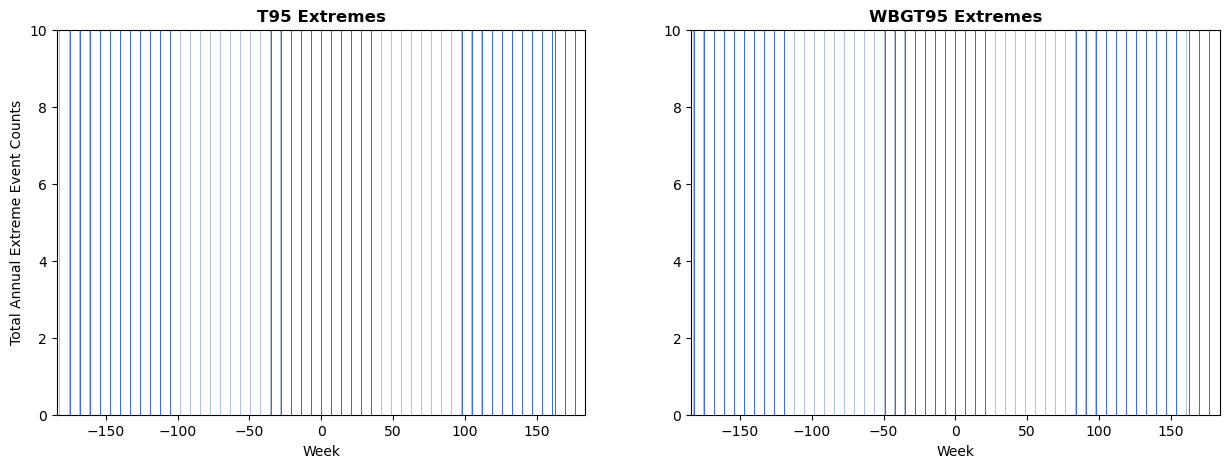

In [38]:
early_color = 'lightsteelblue'
late_color = 'royalblue'

width = 1

#bins = np.arange(-25.5,26.5,1)
bins = np.arange(-1*mid + 0.5,mid + 0.5,1)

fig, axs = plt.subplots(1,2, figsize = (15,5))

T95_hist = axs[0].hist([T95_early_period_shifted, T95_late_period_shifted], bins = bins,
                       color = [early_color, late_color],label=['Early Period 1980-1989', 'Late Period 2015-2024'])

axs[0].set_xlabel('Week')
axs[0].set_ylabel('Total Annual Extreme Event Counts')

axs[0].set_title('T95 Extremes', fontweight = 'bold')
#axs[0].set_ylim([0,0.6])
axs[0].set_ylim([0,10])
axs[0].set_xlim([-1*mid -1 ,mid + 1])
#axs[0].text(1, 55, f"mean shift = {T95_mean_shift_shifted:.2f}")
#axs[0].text(1, 50, f"skew shift = {T95_skew_shift_shifted:.2f}")
#axs[0].text(1, 45, f"kurtosis shift = {T95_kurtosis_shift_shifted:.2f}")

WBGT95_hist = axs[1].hist([WBGT95_early_period_shifted, WBGT95_late_period_shifted], bins = bins,
                       color = [early_color, late_color],label=['Early Period 1980-1989', 'Late Period 2015-2024'])

axs[1].set_xlabel('Week')
axs[1].set_title('WBGT95 Extremes', fontweight = 'bold')
axs[1].set_ylim([0,10])
axs[1].set_xlim([-1*mid -1 ,mid + 1])
#axs[1].text(1, 55, f"mean shift = {WBGT95_mean_shift_shifted:.2f}")
#axs[1].text(1, 50, f"skew shift = {WBGT95_skew_shift_shifted:.2f}")
#axs[1].text(1, 45, f"kurtosis shift = {WBGT95_kurtosis_shift_shifted:.2f}")

# Plot based on normalized data, showing number of events per week

In [5]:
# Save out text files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

mid_month_WBGT = np.loadtxt(save_dir + 'middlemonth_3month_highestWBGT95.txt', delimiter=',')
mid_month_T = np.loadtxt(save_dir + 'middlemonth_3month_highestT95.txt', delimiter=',')

mid_month_WBGT_ds = xr.DataArray(mid_month_WBGT, 
                                coords={'lat': T95_days_daily.lat,'lon': T95_days_daily.lon}, 
                                dims=["lat", "lon"])

mid_month_T_ds = xr.DataArray(mid_month_T, 
                                coords={'lat': T95_days_daily.lat,'lon': T95_days_daily.lon}, 
                                dims=["lat", "lon"])

In [6]:
mid_month_global = mid_month_T_ds

mid_month = int(mid_month_global.sel(lat = lat, lon = lon, method = 'nearest').values)

# Find heat season months
if mid_month == 1:
    heat_season = [12,1,2]
elif mid_month == 12:
    heat_season = [11,12,1]
else:
    heat_season = [mid_month-1,mid_month,mid_month+1]

# Outside months
before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]

# Adjust if this gives negative numbers
before_season = [x if x > 0  else (x+12) for x in before_season_temp]

after_season = [x if x <= 12 else (x-12) for x in after_season_temp]

heat_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(heat_season))).time.dt.dayofyear[0])
heat_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(heat_season))).time.dt.dayofyear[-1])

before_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(before_season))).time.dt.dayofyear[0])
before_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(before_season))).time.dt.dayofyear[-1])

after_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(after_season))).time.dt.dayofyear[0])
after_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(after_season))).time.dt.dayofyear[-1])

NameError: name 'lat' is not defined

In [ ]:
# Use highest frequency month to shift
peak_ind = int(len(T95_early_weekly_frac[T95_early_weekly_frac == np.max(T95_early_weekly_frac)])/2)-1
peak_period_T95_gc = T95_early_weekly_frac[T95_early_weekly_frac == np.max(T95_early_weekly_frac)].time.dt.dayofyear[peak_ind] # or week

peak_period_WBGT95_gc = WBGT95_early_weekly_frac[WBGT95_early_weekly_frac == np.max(WBGT95_early_weekly_frac)].time.dt.dayofyear[peak_ind]

In [ ]:
T95_early_period_temp = np.array([x - int(peak_period_T95_gc) for x in T95_early_weekly_frac.time.dt.dayofyear]) # or mid_month_T95_gc, mid_month_WBGT95_gc
T95_late_period_temp = np.array([x - int(peak_period_T95_gc) for x in T95_early_weekly_frac.time.dt.dayofyear])

WBGT95_early_period_temp = np.array([x - int(peak_period_WBGT95_gc) for x in WBGT95_early_weekly_frac.time.dt.dayofyear]) # or mid_month_T95_gc, mid_month_WBGT95_gc
WBGT95_late_period_temp = np.array([x - int(peak_period_WBGT95_gc) for x in WBGT95_early_weekly_frac.time.dt.dayofyear])

In [ ]:
shift = 366
mid = 183

#shift = 52
#mid = 26

T95_early_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in T95_early_period_temp
]

T95_late_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in T95_late_period_temp
]

WBGT95_early_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in WBGT95_early_period_temp
]

WBGT95_late_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in WBGT95_late_period_temp
]

In [ ]:
# Measure mean, skewness, and kurtosis of each distribution

T95_mean_shift_shifted = np.mean(T95_late_period_shifted) - np.mean(T95_early_period_shifted)
T95_mean_shift_shifted = np.median(T95_late_period_shifted) - np.median(T95_early_period_shifted)
T95_skew_shift_shifted = stats.skew(T95_late_period_shifted) - stats.skew(T95_early_period_shifted)
T95_kurtosis_shift_shifted = stats.kurtosis(T95_late_period_shifted) - stats.kurtosis(T95_early_period_shifted)

WBGT95_mean_shift_shifted = np.median(T95_late_period_shifted) - np.median(WBGT95_early_period_shifted)
WBGT95_mean_shift_shifted = np.mean(WBGT95_late_period_shifted) - np.mean(WBGT95_early_period_shifted)
WBGT95_skew_shift_shifted = stats.skew(WBGT95_late_period_shifted) - stats.skew(WBGT95_early_period_shifted)
WBGT95_kurtosis_shift_shifted = stats.kurtosis(WBGT95_late_period_shifted) - stats.kurtosis(WBGT95_early_period_shifted)

In [ ]:
def shift_DOY(DOY, shift, mid):
    if DOY > mid:
        shifted_DOY = DOY-shift
    elif DOY < -1*mid:
        shifted_DOY = DOY + shift
    else:
        shifted_DOY = DOY

    return shifted_DOY

Text(71.0, 0.093, 'fall')

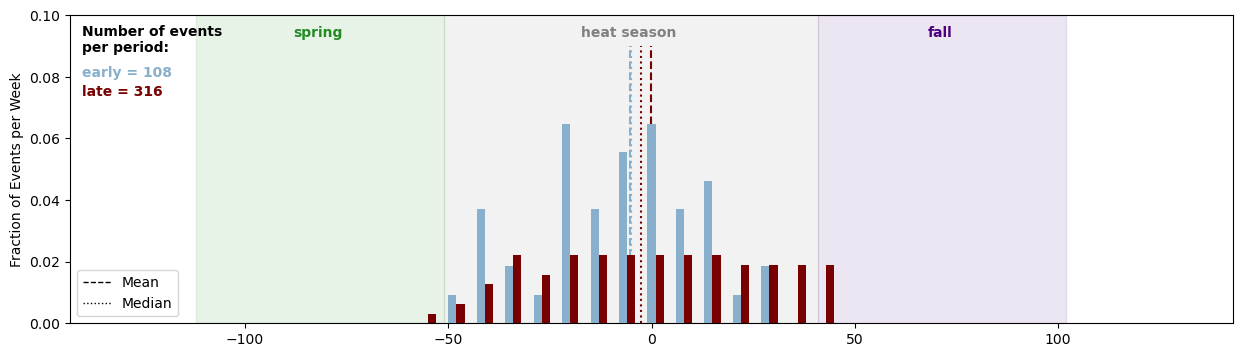

In [56]:
early_color = '#88b0cd'
late_color = '#780000'

shift = 366
mid = shift/2

width = 2

bins = np.arange(-25.5,26.5,1)
ymax = 0.1

mid_month_global = mid_month_T_ds
peak_period = peak_period_T95_gc

fig, axs = plt.subplots(1, figsize = (15,4))

early_bar = axs.bar(T95_early_period_shifted, T95_early_weekly_frac, width, facecolor = early_color, label = 'Early Period 1980-1989', zorder = 10)
late_bar = axs.bar([x + width for x in T95_late_period_shifted], T95_late_weekly_frac, width, facecolor = late_color, label = 'Late Period 2015-2024', zorder = 10)

# Plot vertical lines for mean and median
axs.vlines(np.mean(T95_early_period_gc)-int(peak_period_T95_gc), ymin = 0, ymax = ymax-0.01, color = early_color, linestyle = 'dashed')
axs.vlines(np.median(T95_early_period_gc)-int(peak_period_T95_gc), ymin = 0, ymax = ymax-0.01, color = early_color, linestyle = 'dotted')

axs.vlines(np.mean(T95_late_period_gc)-int(peak_period_T95_gc), ymin = 0, ymax = ymax-0.01, color = late_color, linestyle = 'dashed')
axs.vlines(np.median(T95_late_period_gc)-int(peak_period_T95_gc), ymin = 0, ymax = ymax-0.01, color = late_color, linestyle = 'dotted')

#axs[0].set_xlabel('Week')
axs.set_ylabel('Fraction of Events per Week')

#axs.set_title('T95 Extremes', fontweight = 'bold')
axs.set_ylim([0,ymax])
axs.set_xlim([-1*mid + 40 ,mid -40])
axs.text(0.01, 0.88, f"Number of events\nper period:", color = 'k', transform = axs.transAxes, fontweight = 'bold')
axs.text(0.01, 0.8, f"early = {int(T95_early_total):.0f}", color = early_color, transform = axs.transAxes, fontweight = 'bold')
axs.text(0.01, 0.74, f"late = {int(T95_late_total):.0f}", color = late_color, transform = axs.transAxes, fontweight = 'bold')

# Make my own legend
legend_handles = [
    Line2D([0], [0], color='k', lw=1, linestyle='dashed', label='Mean'),
    Line2D([0], [0], color='k', lw=1, linestyle='dotted', label='Median'),
]
axs.legend(handles=legend_handles, loc='lower left')

#axs[0].text(0.98, 0.9, f"mean shift = {T95_mean_shift_shifted:.2f}", transform = axs[0].transAxes, ha = 'right')
#axs[0].text(0.98, 0.85, f"mean shift = {T95_mean_shift_shifted:.2f}", transform = axs[0].transAxes, ha = 'right')
#axs[0].text(0.98, 0.8, f"skew shift = {T95_skew_shift_shifted:.2f}", transform = axs[0].transAxes, ha = 'right')
#axs[0].text(0.98, 0.75, f"kurtosis shift = {T95_kurtosis_shift_shifted:.2f}", transform = axs[0].transAxes, ha = 'right')

# Plot shaded sections for heat season and shoulder seasons

mid_month = int(mid_month_global.sel(lat = lat, lon = lon, method = 'nearest').values)

# Find heat season months
if mid_month == 1:
    heat_season = [12,1,2]
elif mid_month == 12:
    heat_season = [11,12,1]
else:
    heat_season = [mid_month-1,mid_month,mid_month+1]

# Outside months
before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]

# Adjust if this gives negative numbers
before_season = [x if x > 0  else (x+12) for x in before_season_temp]

after_season = [x if x <= 12 else (x-12) for x in after_season_temp]

heat_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(heat_season))).time.dt.dayofyear[0])
heat_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(heat_season))).time.dt.dayofyear[-1])

before_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(before_season))).time.dt.dayofyear[0])
before_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(before_season))).time.dt.dayofyear[-1])

after_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(after_season))).time.dt.dayofyear[0])
after_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(after_season))).time.dt.dayofyear[-1])

heat_season_start_DOY_shifted = shift_DOY(heat_season_start_DOY - int(peak_period), 366, 183)
heat_season_end_DOY_shifted = shift_DOY(heat_season_end_DOY - int(peak_period), 366, 183)

before_season_start_DOY_shifted = shift_DOY(before_season_start_DOY - int(peak_period), 366, 183)
before_season_end_DOY_shifted = shift_DOY(before_season_end_DOY - int(peak_period), 366, 183)

after_season_start_DOY_shifted = shift_DOY(after_season_start_DOY - int(peak_period), 366, 183)
after_season_end_DOY_shifted = shift_DOY(after_season_end_DOY - int(peak_period), 366, 183)
    
axs.axvspan(heat_season_start_DOY_shifted, heat_season_end_DOY_shifted+1, color='grey', alpha = 0.1, zorder = 0)
axs.text((heat_season_start_DOY_shifted + heat_season_end_DOY_shifted)/2, 0.093, "heat season", color = 'grey', fontweight = 'bold', ha = 'center')

axs.axvspan(before_season_start_DOY_shifted, before_season_end_DOY_shifted+1, color='forestgreen', alpha = 0.1, zorder = 0)
axs.text((before_season_start_DOY_shifted + before_season_end_DOY_shifted)/2, 0.093, "spring", color = 'forestgreen', fontweight = 'bold', ha = 'center')

axs.axvspan(after_season_start_DOY_shifted, after_season_end_DOY_shifted+1, color='indigo', alpha = 0.1, zorder = 0)
axs.text((after_season_start_DOY_shifted + after_season_end_DOY_shifted)/2, 0.093, "fall", color = 'indigo',  fontweight = 'bold', ha = 'center')

# Replot using KDE curves instead of bar plots

I don't really like this <3

Text(85.0, 0.014, 'fall')

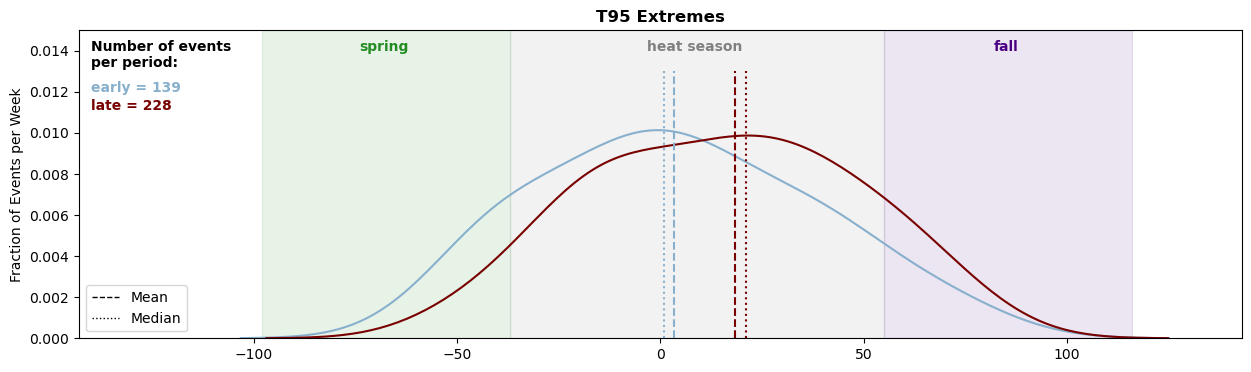

In [87]:
early_color = '#88b0cd'
late_color = '#780000'

shift = 366
mid = shift/2

width = 2

bins = np.arange(-25.5,26.5,1)
ymax = 0.015

mid_month_global = mid_month_T_ds
peak_period = peak_period_T95_gc

fig, axs = plt.subplots(1, figsize = (15,4))

# Calculate KDEs and plot on top of histograms

#early_bar = axs.bar(T95_early_period_shifted, T95_early_weekly_frac, width, facecolor = early_color, label = 'Early Period 1980-1989', zorder = 10)
#late_bar = axs.bar([x + width for x in T95_late_period_shifted], T95_late_weekly_frac, width, facecolor = late_color, label = 'Late Period 2015-2024', zorder = 10)

shifted_early_data = [shift_DOY(x - int(peak_period), 366, 183) for x in T95_early_weekly[T95_early_weekly > 0].time.dt.dayofyear.values]
shifted_late_data = [shift_DOY(x - int(peak_period), 366, 183) for x in T95_late_weekly[T95_late_weekly > 0].time.dt.dayofyear.values]

sns.kdeplot(shifted_early_data, common_norm = True, ax = axs, color = early_color)
sns.kdeplot(shifted_late_data, common_norm = True, ax = axs, color = late_color)


# Plot vertical lines for mean and median
axs.vlines(np.mean(T95_early_period_gc)-int(peak_period_T95_gc), ymin = 0, ymax = ymax-0.002, color = early_color, linestyle = 'dashed')
axs.vlines(np.median(T95_early_period_gc)-int(peak_period_T95_gc), ymin = 0, ymax = ymax-0.002, color = early_color, linestyle = 'dotted')

axs.vlines(np.mean(T95_late_period_gc)-int(peak_period_T95_gc), ymin = 0, ymax = ymax-0.002, color = late_color, linestyle = 'dashed')
axs.vlines(np.median(T95_late_period_gc)-int(peak_period_T95_gc), ymin = 0, ymax = ymax-0.002, color = late_color, linestyle = 'dotted')

#axs[0].set_xlabel('Week')
axs.set_ylabel('Fraction of Events per Week')

axs.set_title('T95 Extremes', fontweight = 'bold')
axs.set_ylim([0,ymax])
axs.set_xlim([-1*mid + 40 ,mid -40])
axs.text(0.01, 0.88, f"Number of events\nper period:", color = 'k', transform = axs.transAxes, fontweight = 'bold')
axs.text(0.01, 0.8, f"early = {int(T95_early_total):.0f}", color = early_color, transform = axs.transAxes, fontweight = 'bold')
axs.text(0.01, 0.74, f"late = {int(T95_late_total):.0f}", color = late_color, transform = axs.transAxes, fontweight = 'bold')

# Make my own legend
legend_handles = [
    Line2D([0], [0], color='k', lw=1, linestyle='dashed', label='Mean'),
    Line2D([0], [0], color='k', lw=1, linestyle='dotted', label='Median'),
]
axs.legend(handles=legend_handles, loc='lower left')

#axs[0].text(0.98, 0.9, f"mean shift = {T95_mean_shift_shifted:.2f}", transform = axs[0].transAxes, ha = 'right')
#axs[0].text(0.98, 0.85, f"mean shift = {T95_mean_shift_shifted:.2f}", transform = axs[0].transAxes, ha = 'right')
#axs[0].text(0.98, 0.8, f"skew shift = {T95_skew_shift_shifted:.2f}", transform = axs[0].transAxes, ha = 'right')
#axs[0].text(0.98, 0.75, f"kurtosis shift = {T95_kurtosis_shift_shifted:.2f}", transform = axs[0].transAxes, ha = 'right')

# Plot shaded sections for heat season and shoulder seasons

mid_month = int(mid_month_global.sel(lat = lat, lon = lon, method = 'nearest').values)

# Find heat season months
if mid_month == 1:
    heat_season = [12,1,2]
elif mid_month == 12:
    heat_season = [11,12,1]
else:
    heat_season = [mid_month-1,mid_month,mid_month+1]

# Outside months
before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]

# Adjust if this gives negative numbers
before_season = [x if x > 0  else (x+12) for x in before_season_temp]

after_season = [x if x <= 12 else (x-12) for x in after_season_temp]

heat_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(heat_season))).time.dt.dayofyear[0])
heat_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(heat_season))).time.dt.dayofyear[-1])

before_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(before_season))).time.dt.dayofyear[0])
before_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(before_season))).time.dt.dayofyear[-1])

after_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(after_season))).time.dt.dayofyear[0])
after_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(after_season))).time.dt.dayofyear[-1])

heat_season_start_DOY_shifted = shift_DOY(heat_season_start_DOY - int(peak_period), 366, 183)
heat_season_end_DOY_shifted = shift_DOY(heat_season_end_DOY - int(peak_period), 366, 183)

before_season_start_DOY_shifted = shift_DOY(before_season_start_DOY - int(peak_period), 366, 183)
before_season_end_DOY_shifted = shift_DOY(before_season_end_DOY - int(peak_period), 366, 183)

after_season_start_DOY_shifted = shift_DOY(after_season_start_DOY - int(peak_period), 366, 183)
after_season_end_DOY_shifted = shift_DOY(after_season_end_DOY - int(peak_period), 366, 183)
    
axs.axvspan(heat_season_start_DOY_shifted, heat_season_end_DOY_shifted+1, color='grey', alpha = 0.1, zorder = 0)
axs.text((heat_season_start_DOY_shifted + heat_season_end_DOY_shifted)/2, 0.014, "heat season", color = 'grey', fontweight = 'bold', ha = 'center')

axs.axvspan(before_season_start_DOY_shifted, before_season_end_DOY_shifted+1, color='forestgreen', alpha = 0.1, zorder = 0)
axs.text((before_season_start_DOY_shifted + before_season_end_DOY_shifted)/2, 0.014, "spring", color = 'forestgreen', fontweight = 'bold', ha = 'center')

axs.axvspan(after_season_start_DOY_shifted, after_season_end_DOY_shifted+1, color='indigo', alpha = 0.1, zorder = 0)
axs.text((after_season_start_DOY_shifted + after_season_end_DOY_shifted)/2, 0.014, "fall", color = 'indigo',  fontweight = 'bold', ha = 'center')

# From job talk slides

In [7]:
def weekly_sum(data):
    
    weekly_list = []
    
    for year in np.unique(data["time.year"]):
        start = pd.Timestamp(f"{year}-01-01")
        end = pd.Timestamp(f"{year}-12-31")
    
        da_year = data.sel(time=slice(start, end))
    
        # Define 7-day bins starting Jan 1, ending Dec 31
        bin_edges = pd.date_range(start, end + pd.Timedelta(days=7), freq="7D")
    
        # Group days into those bins
        weekly_year = da_year.groupby_bins("time", bins=bin_edges, right=False).sum()
    
        # Rename the resulting coordinate so we can use it as "time"
        weekly_year = weekly_year.rename({"time_bins": "time"})
    
        # Set the coordinate values to the left bin edges (start of week)
        weekly_year = weekly_year.assign_coords(time=bin_edges[:-1])
    
        weekly_list.append(weekly_year)
    
    # Concatenate all years together
    weekly = xr.concat(weekly_list, dim="time")

    return weekly

In [8]:
# Import two data files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/'

T95_days_daily = xr.open_dataarray(save_dir + 'global_T95_days_daily_count.nc')
WBGT95_days_daily = xr.open_dataarray(save_dir + 'global_WBGT95_days_daily_count.nc')

In [9]:
# Select early and late periods
period_names = ['Early Period: 1980-1989','Late Period: 2015-2024']
early_period = ['1980-01-01','1989-12-31']
late_period = ['2015-01-01','2024-12-31']

# T
T95_early = T95_days_daily.sel(time = slice(early_period[0],early_period[1]))
T95_early_total = T95_early.sum(dim = 'time')

T95_early_weekly = weekly_sum(T95_early)
T95_early_weekly_frac = (T95_early_weekly/T95_early_total).groupby('time.dayofyear').sum()

T95_late = T95_days_daily.sel(time = slice(late_period[0],late_period[1]))
T95_late_total = T95_late.sum(dim = 'time')

T95_late_weekly = weekly_sum(T95_late)
T95_late_weekly_frac = (T95_late_weekly/T95_late_total).groupby('time.dayofyear').sum()

# WBGT
WBGT95_early = WBGT95_days_daily.sel(time = slice(early_period[0],early_period[1]))
WBGT95_early_total = WBGT95_early.sum(dim = 'time')

WBGT95_early_weekly = weekly_sum(WBGT95_early)
WBGT95_early_weekly_frac = (WBGT95_early_weekly/WBGT95_early_total).groupby('time.dayofyear').sum()

WBGT95_late = WBGT95_days_daily.sel(time = slice(late_period[0],late_period[1]))
WBGT95_late_total = WBGT95_late.sum(dim = 'time')

WBGT95_late_weekly = weekly_sum(WBGT95_late)
WBGT95_late_weekly_frac = (WBGT95_late_weekly/WBGT95_late_total).groupby('time.dayofyear').sum()

In [10]:
# Calculate seasonality distribution for individual location where the asymmetry is dramatic

#location = 'GEORG'
#lat = 31.12
#lon = -84.20

location = 'PHOENIX'
lat = 33.4483
lon = -112.0725

T95_early_gc = T95_early.sel(lat = lat, lon = lon, method = 'nearest')
T95_late_gc = T95_late.sel(lat = lat, lon = lon, method = 'nearest')

WBGT95_early_gc = WBGT95_early.sel(lat = lat, lon = lon, method = 'nearest')
WBGT95_late_gc = WBGT95_late.sel(lat = lat, lon = lon, method = 'nearest')

In [11]:
# T
T95_early_weekly_total = T95_early_gc.groupby('time.week').sum()
T95_early_weekly = weekly_sum(T95_early_gc)
T95_early_total = T95_early_weekly.sum(dim = 'time') # or week for previous setting
T95_early_weekly_frac = (T95_early_weekly/T95_early_total).groupby('time.dayofyear').sum()

T95_late_weekly = weekly_sum(T95_late_gc)
T95_late_total = T95_late_weekly.sum(dim = 'time')
T95_late_weekly_frac = (T95_late_weekly/T95_late_total).groupby('time.dayofyear').sum()

# WBGT
WBGT95_early_weekly_total = WBGT95_early_gc.groupby('time.week').sum()
WBGT95_early_weekly = weekly_sum(WBGT95_early_gc)
WBGT95_early_total = WBGT95_early_weekly.sum(dim = 'time') # or week for previous setting
WBGT95_early_weekly_frac = (WBGT95_early_weekly/WBGT95_early_total).groupby('time.dayofyear').sum()

WBGT95_late_weekly = weekly_sum(WBGT95_late_gc)
WBGT95_late_total = WBGT95_late_weekly.sum(dim = 'time')
WBGT95_late_weekly_frac = (WBGT95_late_weekly/WBGT95_late_total).groupby('time.dayofyear').sum()

In [12]:
T95_early_period_gc = T95_early_gc.where(T95_early_gc > 0, drop = True).time.dt.dayofyear # or week, for previous setting
T95_late_period_gc = T95_late_gc.where(T95_late_gc > 0, drop = True).time.dt.dayofyear

WBGT95_early_period_gc = WBGT95_early_gc.where(WBGT95_early_gc > 0, drop = True).time.dt.dayofyear # or week, for previous setting
WBGT95_late_period_gc = WBGT95_late_gc.where(WBGT95_late_gc > 0, drop = True).time.dt.dayofyear

In [13]:
# Use highest frequency month to shift
peak_period_T95_gc = stats.mode(T95_early_period_gc.values).mode

peak_period_WBGT95_gc = stats.mode(WBGT95_early_period_gc.values).mode

In [14]:
T95_early_period_temp = np.array([x - int(peak_period_T95_gc) for x in T95_early_period_gc.values]) # or mid_month_T95_gc, mid_month_WBGT95_gc
T95_late_period_temp = np.array([x - int(peak_period_T95_gc) for x in T95_late_period_gc.values])

In [15]:
shift = 366
mid = 183

#shift = 52
#mid = 26

T95_early_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in T95_early_period_temp
]

T95_late_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in T95_late_period_temp
]

In [16]:
# Measure mean, skewness, and kurtosis of each distribution

T95_mean_shift_shifted = np.mean(T95_late_period_shifted) - np.mean(T95_early_period_shifted)
T95_skew_shift_shifted = stats.skew(T95_late_period_shifted) - stats.skew(T95_early_period_shifted)
T95_kurtosis_shift_shifted = stats.kurtosis(T95_late_period_shifted) - stats.kurtosis(T95_early_period_shifted)

## Plot based on normalized data, showing number of events per week

In [17]:
# Save out text files
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

mid_month_WBGT = np.loadtxt(save_dir + 'middlemonth_3month_highestWBGT95.txt', delimiter=',')
mid_month_T = np.loadtxt(save_dir + 'middlemonth_3month_highestT95.txt', delimiter=',')

mid_month_WBGT_ds = xr.DataArray(mid_month_WBGT, 
                                coords={'lat': T95_days_daily.lat,'lon': T95_days_daily.lon}, 
                                dims=["lat", "lon"])

mid_month_T_ds = xr.DataArray(mid_month_T, 
                                coords={'lat': T95_days_daily.lat,'lon': T95_days_daily.lon}, 
                                dims=["lat", "lon"])

In [18]:
mid_month_global = mid_month_T_ds

mid_month = int(mid_month_global.sel(lat = lat, lon = lon, method = 'nearest').values)

# Find heat season months
if mid_month == 1:
    heat_season = [12,1,2]
elif mid_month == 12:
    heat_season = [11,12,1]
else:
    heat_season = [mid_month-1,mid_month,mid_month+1]

# Outside months
before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]

# Adjust if this gives negative numbers
before_season = [x if x > 0  else (x+12) for x in before_season_temp]

after_season = [x if x <= 12 else (x-12) for x in after_season_temp]

heat_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(heat_season))).time.dt.dayofyear[0])
heat_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(heat_season))).time.dt.dayofyear[-1])

before_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(before_season))).time.dt.dayofyear[0])
before_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(before_season))).time.dt.dayofyear[-1])

after_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(after_season))).time.dt.dayofyear[0])
after_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(after_season))).time.dt.dayofyear[-1])

In [19]:
# Use highest frequency month to shift
peak_ind_T = int(len(T95_early_weekly_frac[T95_early_weekly_frac == np.max(T95_early_weekly_frac)])/2)-1
peak_period_T95_gc = T95_early_weekly_frac[T95_early_weekly_frac == np.max(T95_early_weekly_frac)].dayofyear[peak_ind_T] # or week

peak_ind_WBGT = int(len(WBGT95_early_weekly_frac[WBGT95_early_weekly_frac == np.max(WBGT95_early_weekly_frac)])/2)-1
peak_period_WBGT95_gc = WBGT95_early_weekly_frac[WBGT95_early_weekly_frac == np.max(WBGT95_early_weekly_frac)].dayofyear[peak_ind_WBGT] # or week

In [20]:
peak_period_T95_gc = peak_period_T95_gc + 30
peak_period_WBGT95_gc = peak_period_WBGT95_gc

In [21]:
T95_early_period_temp = np.array([x - int(peak_period_T95_gc) for x in T95_early_weekly_frac.dayofyear]) # or mid_month_T95_gc, mid_month_WBGT95_gc
T95_late_period_temp = np.array([x - int(peak_period_T95_gc) for x in T95_early_weekly_frac.dayofyear])

WBGT95_early_period_temp = np.array([x - int(peak_period_WBGT95_gc) for x in WBGT95_early_weekly_frac.dayofyear]) # or mid_month_T95_gc, mid_month_WBGT95_gc
WBGT95_late_period_temp = np.array([x - int(peak_period_WBGT95_gc) for x in WBGT95_early_weekly_frac.dayofyear])

In [22]:
shift = 366
mid = 183

#shift = 52
#mid = 26

T95_early_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in T95_early_period_temp
]

T95_late_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in T95_late_period_temp
]

WBGT95_early_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in WBGT95_early_period_temp
]

WBGT95_late_period_shifted = [
    (x-shift) if x > mid else
    (x+shift) if x < -1*mid else
    x
    for x in WBGT95_late_period_temp
]

In [23]:
def shift_DOY(DOY, shift, mid):
    if DOY > mid:
        shifted_DOY = DOY-shift
    elif DOY < -1*mid:
        shifted_DOY = DOY + shift
    else:
        shifted_DOY = DOY

    return shifted_DOY

In [24]:
def plot_distribution_figure(early_data, late_data, yaxis = 'number', plot_late = True, shading = True, annotations = True):

    if yaxis == 'number':
        ymax = 9
        text_shift = 0.75
    if yaxis == 'frac':
        ymax = 0.09
        text_shift = 0.005
    
    early_color = '#88b0cd'
    late_color = '#780000'
    
    shift = 366
    mid = shift/2
    
    width = 2
    
    bins = np.arange(-25.5,26.5,1)
    
    mid_month_global = mid_month_T_ds
    peak_period = peak_period_T95_gc
    
    fontsize_main = 14
    plt.rcParams.update({'font.size': fontsize_main})
    
    fig, axs = plt.subplots(1, figsize = (15,4), dpi = 600)
    
    early_bar = axs.bar(T95_early_period_shifted, early_data, width, facecolor = early_color, label = 'Early Period 1980-1989', zorder = 10) # T95_early_weekly

    axs.set_ylabel('Fraction of Events per Week')
    axs.set_xlabel('Days Before/After Peak Heat Week')
    
    axs.set_ylim([0,ymax])
    axs.set_xlim([-1*mid + 40 ,mid -40])
    axs.text(0.01, 0.85, f"Events per\nPeriod:", color = 'k', transform = axs.transAxes, fontweight = 'bold')
    axs.text(0.01, 0.77, f"1980-1989 = {int(T95_early_total):.0f}", color = early_color, transform = axs.transAxes, fontsize = fontsize_main-2, fontweight = 'bold')

    # Update ticks to months
    ticks_unshifted = [1,32,61,92,122,153,183,214,245,275,306,336]
    ticks_shifted = [shift_DOY(x - int(peak_period), 366, 183) for x in ticks_unshifted]
    tick_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    
    axs.set_xticks(ticks_shifted)
    axs.set_xticklabels(tick_labels)

    if plot_late == True:        
        late_bar = axs.bar([x + width for x in T95_late_period_shifted], late_data, width, facecolor = late_color, label = 'Late Period 2015-2024', zorder = 10)
        axs.text(0.01, 0.71, f"2015-2024 = {int(T95_late_total):.0f}", color = late_color, transform = axs.transAxes, fontsize = fontsize_main-2, fontweight = 'bold')

    if shading == True:
        # Plot shaded sections for heat season and shoulder seasons
        mid_month = int(mid_month_global.sel(lat = lat, lon = lon, method = 'nearest').values)
        
        # Find heat season months
        if mid_month == 1:
            heat_season = [12,1,2]
        elif mid_month == 12:
            heat_season = [11,12,1]
        else:
            heat_season = [mid_month-1,mid_month,mid_month+1]
        
        # Outside months
        before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
        after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]
        
        # Adjust if this gives negative numbers
        before_season = [x if x > 0  else (x+12) for x in before_season_temp]
        
        after_season = [x if x <= 12 else (x-12) for x in after_season_temp]
        
        heat_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(heat_season))).time.dt.dayofyear[0])
        heat_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(heat_season))).time.dt.dayofyear[-1])
        
        before_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(before_season))).time.dt.dayofyear[0])
        before_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(before_season))).time.dt.dayofyear[-1])
        
        after_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(after_season))).time.dt.dayofyear[0])
        after_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(after_season))).time.dt.dayofyear[-1])
        
        heat_season_start_DOY_shifted = shift_DOY(heat_season_start_DOY - int(peak_period), 366, 183)
        heat_season_end_DOY_shifted = shift_DOY(heat_season_end_DOY - int(peak_period), 366, 183)
        
        before_season_start_DOY_shifted = shift_DOY(before_season_start_DOY - int(peak_period), 366, 183)
        before_season_end_DOY_shifted = shift_DOY(before_season_end_DOY - int(peak_period), 366, 183)
        
        after_season_start_DOY_shifted = shift_DOY(after_season_start_DOY - int(peak_period), 366, 183)
        after_season_end_DOY_shifted = shift_DOY(after_season_end_DOY - int(peak_period), 366, 183)
            
        axs.axvspan(heat_season_start_DOY_shifted, heat_season_end_DOY_shifted+1, color='grey', alpha = 0.1, zorder = 0)
        axs.text((heat_season_start_DOY_shifted + heat_season_end_DOY_shifted)/2, ymax - text_shift, "heat season", color = 'grey', fontweight = 'bold', ha = 'center') 
        
        axs.axvspan(before_season_start_DOY_shifted, before_season_end_DOY_shifted+1, color='forestgreen', alpha = 0.1, zorder = 0)
        axs.text((before_season_start_DOY_shifted + before_season_end_DOY_shifted)/2, ymax - text_shift, "pre-season", color = 'forestgreen', fontweight = 'bold', ha = 'center')
        
        axs.axvspan(after_season_start_DOY_shifted, after_season_end_DOY_shifted+1, color='indigo', alpha = 0.1, zorder = 0)
        axs.text((after_season_start_DOY_shifted + after_season_end_DOY_shifted)/2, ymax - text_shift, "post-season", color = 'indigo',  fontweight = 'bold', ha = 'center')

    if annotations == True:
        ax2 = axs.twinx()
        ax2.boxplot(

SyntaxError: incomplete input (3665508872.py, line 100)

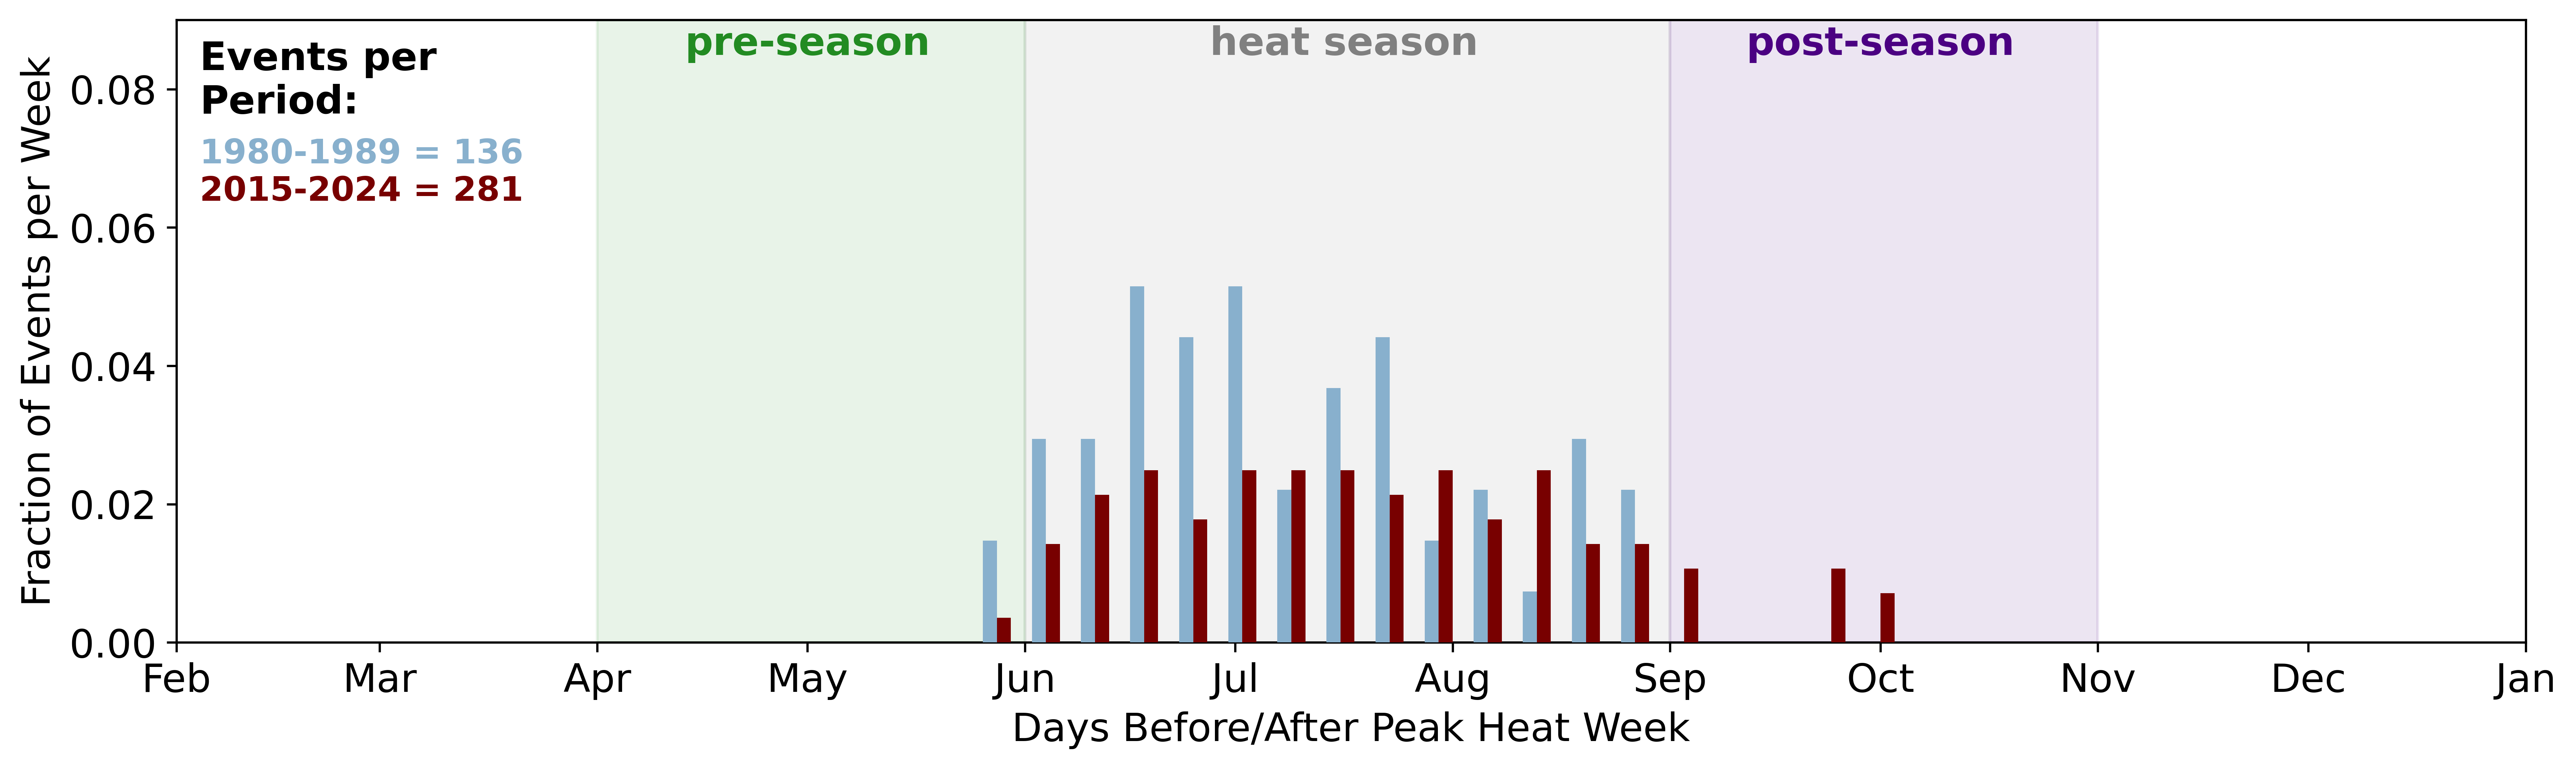

In [23]:
plot_distribution_figure(T95_early_weekly_frac, T95_late_weekly_frac,yaxis = 'frac', plot_late = True, shading = True)

In [25]:
# Define a function that returns change in mean, skewness, and kurtosis
def distribution_shifts_weekly(early_data,late_data):
    
    # At each location, record the week when each extreme event happened
    early_counts = early_data.where(early_data > 0, drop = True).time.dt.dayofyear
    late_counts = late_data.where(late_data > 0, drop = True).time.dt.dayofyear
    
    early_period = early_counts
    late_period = late_counts
    
    # Use highest frequency day to shift
    peak_period = peak_period_T95_gc
    
    early_period_temp = np.array([x - int(peak_period) for x in early_period.values]) # or mid_month_T95_gc, mid_month_WBGT95_gc
    late_period_temp = np.array([x - int(peak_period) for x in late_period.values])
    
    shift = 366
    mid = 183
    
    early_period_shifted = [
        (x-shift) if x > mid else
        (x+shift) if x < -1*mid else
        x
        for x in early_period_temp
    ]
    
    late_period_shifted = [
        (x-shift) if x > mid else
        (x+shift) if x < -1*mid else
        x
        for x in late_period_temp
    ]
    
    if (len(early_period_temp) > 0) & (len(late_period_temp) > 0):
    
        # Calculate changes in distributions
        min_early = np.min(early_period_shifted)
        max_early = np.max(early_period_shifted)
        median_early = np.median(early_period_shifted)
        lower_quartile_early = np.quantile(early_period_shifted, 0.25)
        upper_quartile_early = np.quantile(early_period_shifted, 0.75)

        min_late = np.min(late_period_shifted)
        max_late = np.max(late_period_shifted)
        median_late = np.median(late_period_shifted)
        lower_quartile_late = np.quantile(late_period_shifted, 0.25)
        upper_quartile_late = np.quantile(late_period_shifted, 0.75)
    
    else:
        min_early = np.nan
        max_early = np.nan
        median_early = np.nan
        lower_quartile_early = np.nan
        upper_quartile_early = np.nan

        min_late = np.nan
        max_late = np.nan
        median_late = np.nan
        lower_quartile_late = np.nan
        upper_quartile_late = np.nan

    return np.array([min_early, max_early, median_early, lower_quartile_early, upper_quartile_early, min_late, max_late, median_late, lower_quartile_late, upper_quartile_late])

In [72]:
[min_early, max_early, median_early, lower_quartile_early, upper_quartile_early, min_late, max_late, median_late, lower_quartile_late, upper_quartile_late] = distribution_shifts_weekly(T95_early_gc,T95_late_gc)

In [106]:
def distribution_shifts_weekly(early_data,late_data):
    
    # At each location, record the week when each extreme event happened
    early_counts = early_data.where(early_data > 0, drop = True).time.dt.dayofyear
    late_counts = late_data.where(late_data > 0, drop = True).time.dt.dayofyear
    
    early_period = early_counts
    late_period = late_counts
    
    # Use highest frequency day to shift
    peak_period = peak_period_T95_gc
    
    early_period_temp = np.array([x - int(peak_period) for x in early_period.values]) # or mid_month_T95_gc, mid_month_WBGT95_gc
    late_period_temp = np.array([x - int(peak_period) for x in late_period.values])
    
    shift = 366
    mid = 183
    
    early_period_shifted = [
        (x-shift) if x > mid else
        (x+shift) if x < -1*mid else
        x
        for x in early_period_temp
    ]
    
    late_period_shifted = [
        (x-shift) if x > mid else
        (x+shift) if x < -1*mid else
        x
        for x in late_period_temp
    ]
    early_color = '#88b0cd'
    late_color = '#780000'
    colors = [early_color, late_color]
    medianprops = dict(linestyle='-', linewidth=2.5, color='w')
    
    bplot = plt.boxplot([early_period_shifted,late_period_shifted], patch_artist = True,  vert = False, sym = '', medianprops = medianprops)
    
    for patch, color in zip(bplot['boxes'], colors):
        
        patch.set_facecolor(color)

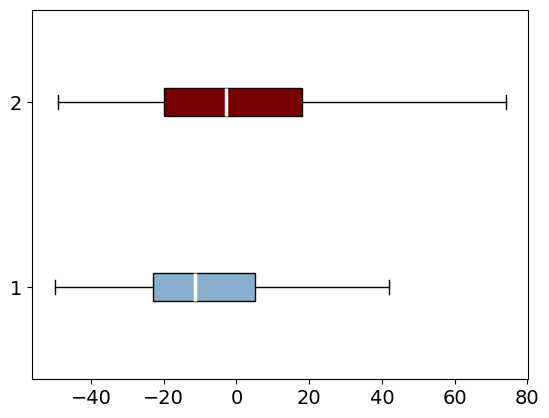

In [107]:
distribution_shifts_weekly(T95_early_gc,T95_late_gc)

In [36]:
# Plot this on top of figure

def plot_distribution_figure(early_data, late_data, box_early_data, box_late_data, mid_month_ds, peak_period_gc, yaxis = 'number', plot_late = True, shading = True, annotations = True):

    if yaxis == 'number':
        ymax = 9
        text_shift = 0.75
    if yaxis == 'frac':
        ymax = 0.28
        text_shift = 0.025 # was 0.015
        yticks = [0,0.05,0.1,0.15,0.2,0.25]
    
    early_color = '#88b0cd'
    late_color = '#780000'
    
    shift = 366
    mid = shift/2
    
    width = 2
    
    bins = np.arange(-25.5,26.5,1)
    
    mid_month_global = mid_month_ds
    peak_period = peak_period_gc
    
    fontsize_main = 14
    plt.rcParams.update({'font.size': fontsize_main})
    
    fig, axs = plt.subplots(1, figsize = (15,4), dpi = 600)
    
    early_bar = axs.bar(T95_early_period_shifted, early_data, width, facecolor = early_color, label = 'Early Period 1980-1989', zorder = 10) # T95_early_weekly

    axs.set_ylabel('Fraction of Events per Week')
    axs.set_xlabel('Days Before/After Peak Heat Week')
    
    axs.set_ylim([0,ymax])
    axs.set_xlim([-1*mid + 40 ,mid -40])
    axs.text(0.01, 0.85, f"# events\nper period:", color = 'k', transform = axs.transAxes, fontweight = 'bold')
    axs.text(0.01, 0.77, f"1980-1989 = {int(T95_early_total):.0f}", color = early_color, transform = axs.transAxes, fontsize = fontsize_main-2, fontweight = 'bold')

    # Update ticks to months
    ticks_unshifted = [1,32,61,92,122,153,183,214,245,275,306,336]
    ticks_shifted = [shift_DOY(x - int(peak_period), 366, 183) for x in ticks_unshifted]
    tick_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    
    axs.set_xticks(ticks_shifted)
    axs.set_xticklabels(tick_labels)
    axs.set_yticks(yticks)

    if plot_late == True:        
        late_bar = axs.bar([x + width for x in T95_late_period_shifted], late_data, width, facecolor = late_color, label = 'Late Period 2015-2024', zorder = 10)
        axs.text(0.01, 0.71, f"2015-2024 = {int(T95_late_total):.0f}", color = late_color, transform = axs.transAxes, fontsize = fontsize_main-2, fontweight = 'bold')

    if shading == True:
        # Plot shaded sections for heat season and shoulder seasons
        mid_month = int(mid_month_global.sel(lat = lat, lon = lon, method = 'nearest').values)
        
        # Find heat season months
        if mid_month == 1:
            heat_season = [12,1,2]
        elif mid_month == 12:
            heat_season = [11,12,1]
        else:
            heat_season = [mid_month-1,mid_month,mid_month+1]
        
        # Outside months
        before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
        after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]
        
        # Adjust if this gives negative numbers
        before_season = [x if x > 0  else (x+12) for x in before_season_temp]
        
        after_season = [x if x <= 12 else (x-12) for x in after_season_temp]
        
        heat_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(heat_season))).time.dt.dayofyear[0])
        heat_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(heat_season))).time.dt.dayofyear[-1])
        
        before_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(before_season))).time.dt.dayofyear[0])
        before_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(before_season))).time.dt.dayofyear[-1])
        
        after_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(after_season))).time.dt.dayofyear[0])
        after_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(after_season))).time.dt.dayofyear[-1])
        
        heat_season_start_DOY_shifted = shift_DOY(heat_season_start_DOY - int(peak_period), 366, 183)
        heat_season_end_DOY_shifted = shift_DOY(heat_season_end_DOY - int(peak_period), 366, 183)
        
        before_season_start_DOY_shifted = shift_DOY(before_season_start_DOY - int(peak_period), 366, 183)
        before_season_end_DOY_shifted = shift_DOY(before_season_end_DOY - int(peak_period), 366, 183)
        
        after_season_start_DOY_shifted = shift_DOY(after_season_start_DOY - int(peak_period), 366, 183)
        after_season_end_DOY_shifted = shift_DOY(after_season_end_DOY - int(peak_period), 366, 183)
            
        axs.axvspan(heat_season_start_DOY_shifted, heat_season_end_DOY_shifted+1, color='grey', alpha = 0.1, zorder = 0)
        axs.text((heat_season_start_DOY_shifted + heat_season_end_DOY_shifted)/2, ymax - text_shift, "heat season", color = 'grey', fontweight = 'bold', ha = 'center') 
        
        axs.axvspan(before_season_start_DOY_shifted, before_season_end_DOY_shifted+1, color='forestgreen', alpha = 0.1, zorder = 0)
        axs.text((before_season_start_DOY_shifted + before_season_end_DOY_shifted)/2, ymax - text_shift, "pre-season", color = 'forestgreen', fontweight = 'bold', ha = 'center')
        
        axs.axvspan(after_season_start_DOY_shifted, after_season_end_DOY_shifted+1, color='indigo', alpha = 0.1, zorder = 0)
        axs.text((after_season_start_DOY_shifted + after_season_end_DOY_shifted)/2, ymax - text_shift, "post-season", color = 'indigo',  fontweight = 'bold', ha = 'center')

    if annotations == True:

        # At each location, record the week when each extreme event happened
        early_counts = box_early_data.where(box_early_data > 0, drop = True).time.dt.dayofyear
        late_counts = box_late_data.where(box_late_data > 0, drop = True).time.dt.dayofyear
        
        early_period = early_counts
        late_period = late_counts
        
        # Use highest frequency day to shift
        peak_period = peak_period_T95_gc
        
        early_period_temp = np.array([x - int(peak_period) for x in early_period.values]) # or mid_month_T95_gc, mid_month_WBGT95_gc
        late_period_temp = np.array([x - int(peak_period) for x in late_period.values])
        
        early_period_shifted = [
            (x-shift) if x > mid else
            (x+shift) if x < -1*mid else
            x
            for x in early_period_temp
        ]
        
        late_period_shifted = [
            (x-shift) if x > mid else
            (x+shift) if x < -1*mid else
            x
            for x in late_period_temp
        ]
        
        ax2 = axs.twinx()

        colors = [early_color, late_color]
        medianprops = dict(linestyle='-', linewidth=2.5, color='grey')
        boxprops = dict(linestyle='-', linewidth=4, color='k')
        
        bplot = ax2.boxplot([early_period_shifted,late_period_shifted], patch_artist = True,  
                            vert = False, sym = '', whis = 0, widths = 0.55,  showcaps = False,
                            medianprops = medianprops, boxprops = boxprops)
        
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_edgecolor(color)
            patch.set_facecolor('#f2f2f2')

        ax2.set_ylim([-6,4])
        ax2.set_yticks([])

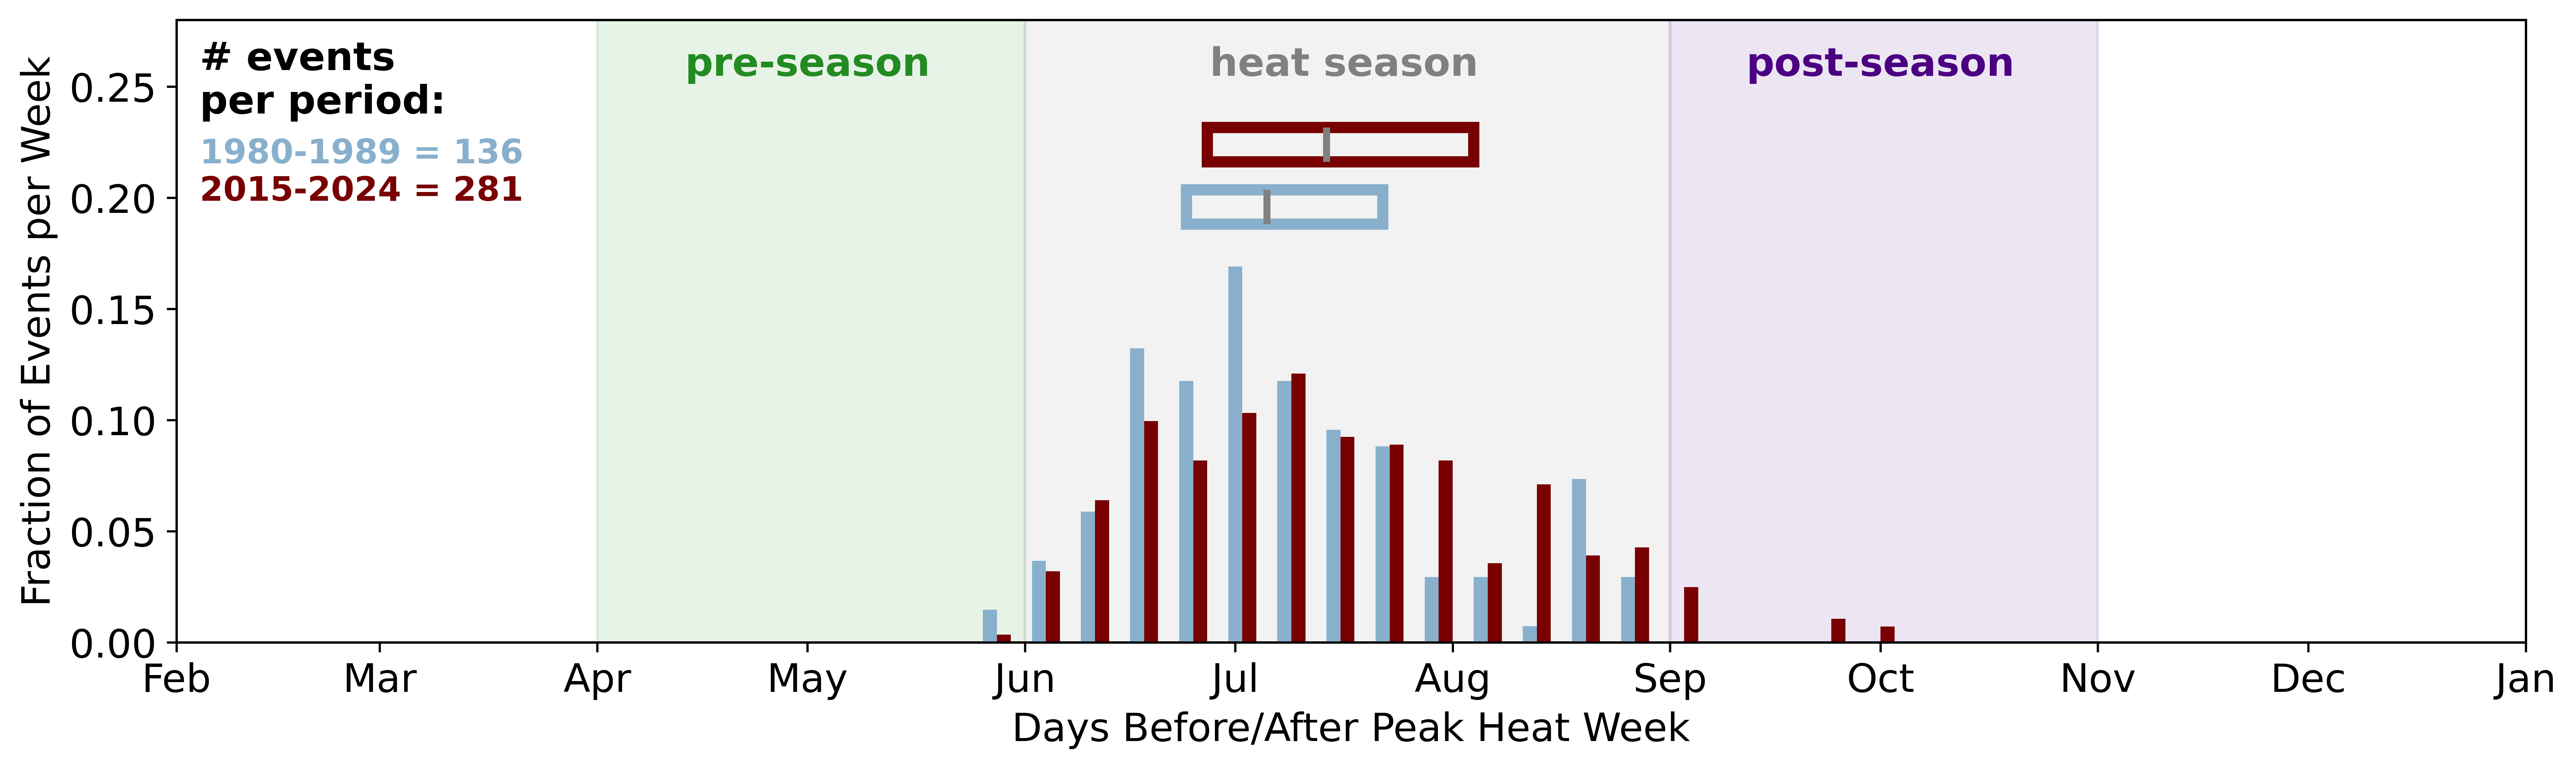

In [38]:
plot_distribution_figure(T95_early_weekly_frac, T95_late_weekly_frac, T95_early_gc,T95_late_gc, mid_month_T_ds,peak_period_T95_gc, yaxis = 'frac')

In [25]:
# Plot both together

def plot_distribution_figure(early_data, late_data, box_early_data, box_late_data, event, axs, yaxis = 'number', plot_late = True, shading = True, annotations = True):

    if yaxis == 'number':
        ymax = 9
        text_shift = 0.75
    if yaxis == 'frac':
        ymax = 0.28
        text_shift = 0.02
        yticks = [0,0.05,0.1,0.15,0.2,0.25]
    
    early_color = '#88b0cd'
    late_color = '#780000'
    
    shift = 366
    mid = shift/2
    
    width = 2
    
    bins = np.arange(-25.5,26.5,1)

    if event == 'T':
        mid_month_global = mid_month_T_ds
        peak_period = peak_period_T95_gc
        early_period_shifted = T95_early_period_shifted
        late_period_shifted = T95_late_period_shifted
        early_total = T95_early_total
        late_total = T95_late_total
        early_gc = T95_early_gc
    elif event == 'WBGT':
        mid_month_global = mid_month_WBGT_ds
        peak_period = peak_period_WBGT95_gc
        early_period_shifted = WBGT95_early_period_shifted
        late_period_shifted = WBGT95_late_period_shifted
        early_total = WBGT95_early_total
        late_total = WBGT95_late_total
        early_gc = WBGT95_early_gc     
    
    early_bar = axs.bar(early_period_shifted, early_data, width, facecolor = early_color, label = 'Early Period 1980-1989', zorder = 10) # T95_early_weekly

    axs.set_ylabel('Fraction of Events per Week')
    
    axs.set_ylim([0,ymax])
    axs.set_xlim([-1*mid + 40 ,mid -40])
    axs.text(0.01, 0.85, f"Events per\nPeriod:", color = 'k', transform = axs.transAxes, fontweight = 'bold')
    axs.text(0.01, 0.77, f"1980-1989 = {int(early_total):.0f}", color = early_color, transform = axs.transAxes, fontsize = fontsize_main-2, fontweight = 'bold')

    # Update ticks to months
    ticks_unshifted = [1,32,61,92,122,153,183,214,245,275,306,336]
    ticks_shifted = [shift_DOY(x - int(peak_period), 366, 183) for x in ticks_unshifted]
    tick_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    
    axs.set_xticks(ticks_shifted)
    axs.set_xticklabels(tick_labels)
    axs.set_yticks(yticks)

    if plot_late == True:        
        late_bar = axs.bar([x + width for x in late_period_shifted], late_data, width, facecolor = late_color, label = 'Late Period 2015-2024', zorder = 10)
        axs.text(0.01, 0.71, f"2015-2024 = {int(late_total):.0f}", color = late_color, transform = axs.transAxes, fontsize = fontsize_main-2, fontweight = 'bold')

    if shading == True:
        # Plot shaded sections for heat season and shoulder seasons
        mid_month = int(mid_month_global.sel(lat = lat, lon = lon, method = 'nearest').values)
        
        # Find heat season months
        if mid_month == 1:
            heat_season = [12,1,2]
        elif mid_month == 12:
            heat_season = [11,12,1]
        else:
            heat_season = [mid_month-1,mid_month,mid_month+1]
        
        # Outside months
        before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
        after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]
        
        # Adjust if this gives negative numbers
        before_season = [x if x > 0  else (x+12) for x in before_season_temp]
        
        after_season = [x if x <= 12 else (x-12) for x in after_season_temp]
        
        heat_season_start_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == min(heat_season))).time.dt.dayofyear[0])
        heat_season_end_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == max(heat_season))).time.dt.dayofyear[-1])
        
        before_season_start_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == min(before_season))).time.dt.dayofyear[0])
        before_season_end_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == max(before_season))).time.dt.dayofyear[-1])
        
        after_season_start_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == min(after_season))).time.dt.dayofyear[0])
        after_season_end_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == max(after_season))).time.dt.dayofyear[-1])
        
        heat_season_start_DOY_shifted = shift_DOY(heat_season_start_DOY - int(peak_period), 366, 183)
        heat_season_end_DOY_shifted = shift_DOY(heat_season_end_DOY - int(peak_period), 366, 183)
        
        before_season_start_DOY_shifted = shift_DOY(before_season_start_DOY - int(peak_period), 366, 183)
        before_season_end_DOY_shifted = shift_DOY(before_season_end_DOY - int(peak_period), 366, 183)
        
        after_season_start_DOY_shifted = shift_DOY(after_season_start_DOY - int(peak_period), 366, 183)
        after_season_end_DOY_shifted = shift_DOY(after_season_end_DOY - int(peak_period), 366, 183)
            
        axs.axvspan(heat_season_start_DOY_shifted, heat_season_end_DOY_shifted+1, color='grey', alpha = 0.1, zorder = 0)
        axs.text((heat_season_start_DOY_shifted + heat_season_end_DOY_shifted)/2, ymax - text_shift, "heat season", color = 'grey', fontweight = 'bold', ha = 'center') 
        
        axs.axvspan(before_season_start_DOY_shifted, before_season_end_DOY_shifted+1, color='forestgreen', alpha = 0.1, zorder = 0)
        axs.text((before_season_start_DOY_shifted + before_season_end_DOY_shifted)/2, ymax - text_shift, "pre-season", color = 'forestgreen', fontweight = 'bold', ha = 'center')
        
        axs.axvspan(after_season_start_DOY_shifted, after_season_end_DOY_shifted+1, color='indigo', alpha = 0.1, zorder = 0)
        axs.text((after_season_start_DOY_shifted + after_season_end_DOY_shifted)/2, ymax - text_shift, "post-season", color = 'indigo',  fontweight = 'bold', ha = 'center')

    if annotations == True:

        # At each location, record the week when each extreme event happened
        early_counts = box_early_data.where(box_early_data > 0, drop = True).time.dt.dayofyear
        late_counts = box_late_data.where(box_late_data > 0, drop = True).time.dt.dayofyear
        
        early_period = early_counts
        late_period = late_counts
        
        # Use highest frequency day to shift
        
        early_period_temp = np.array([x - int(peak_period) for x in early_period.values]) # or mid_month_T95_gc, mid_month_WBGT95_gc
        late_period_temp = np.array([x - int(peak_period) for x in late_period.values])
        
        early_period_shifted = [
            (x-shift) if x > mid else
            (x+shift) if x < -1*mid else
            x
            for x in early_period_temp
        ]
        
        late_period_shifted = [
            (x-shift) if x > mid else
            (x+shift) if x < -1*mid else
            x
            for x in late_period_temp
        ]
        
        ax2 = axs.twinx()

        colors = [early_color, late_color]
        medianprops = dict(linestyle='-', linewidth=2.5, color='grey')
        boxprops = dict(linestyle='-', linewidth=4, color='k')
        
        bplot = ax2.boxplot([early_period_shifted,late_period_shifted], patch_artist = True,  
                            vert = False, sym = '', whis = 0, widths = 0.55,  showcaps = False,
                            medianprops = medianprops, boxprops = boxprops)
        
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_edgecolor(color)
            patch.set_facecolor('#f2f2f2')

        ax2.set_ylim([-6,4])
        ax2.set_yticks([])

In [26]:
shapefile_dir = '/gpfsm/dnb33/civanovi/data/cartopy_shape_files/'

coastlines = shp.Reader(shapefile_dir + 'ne_10m_coastline/ne_10m_coastline.shp')
states = shp.Reader(shapefile_dir + 'ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp')

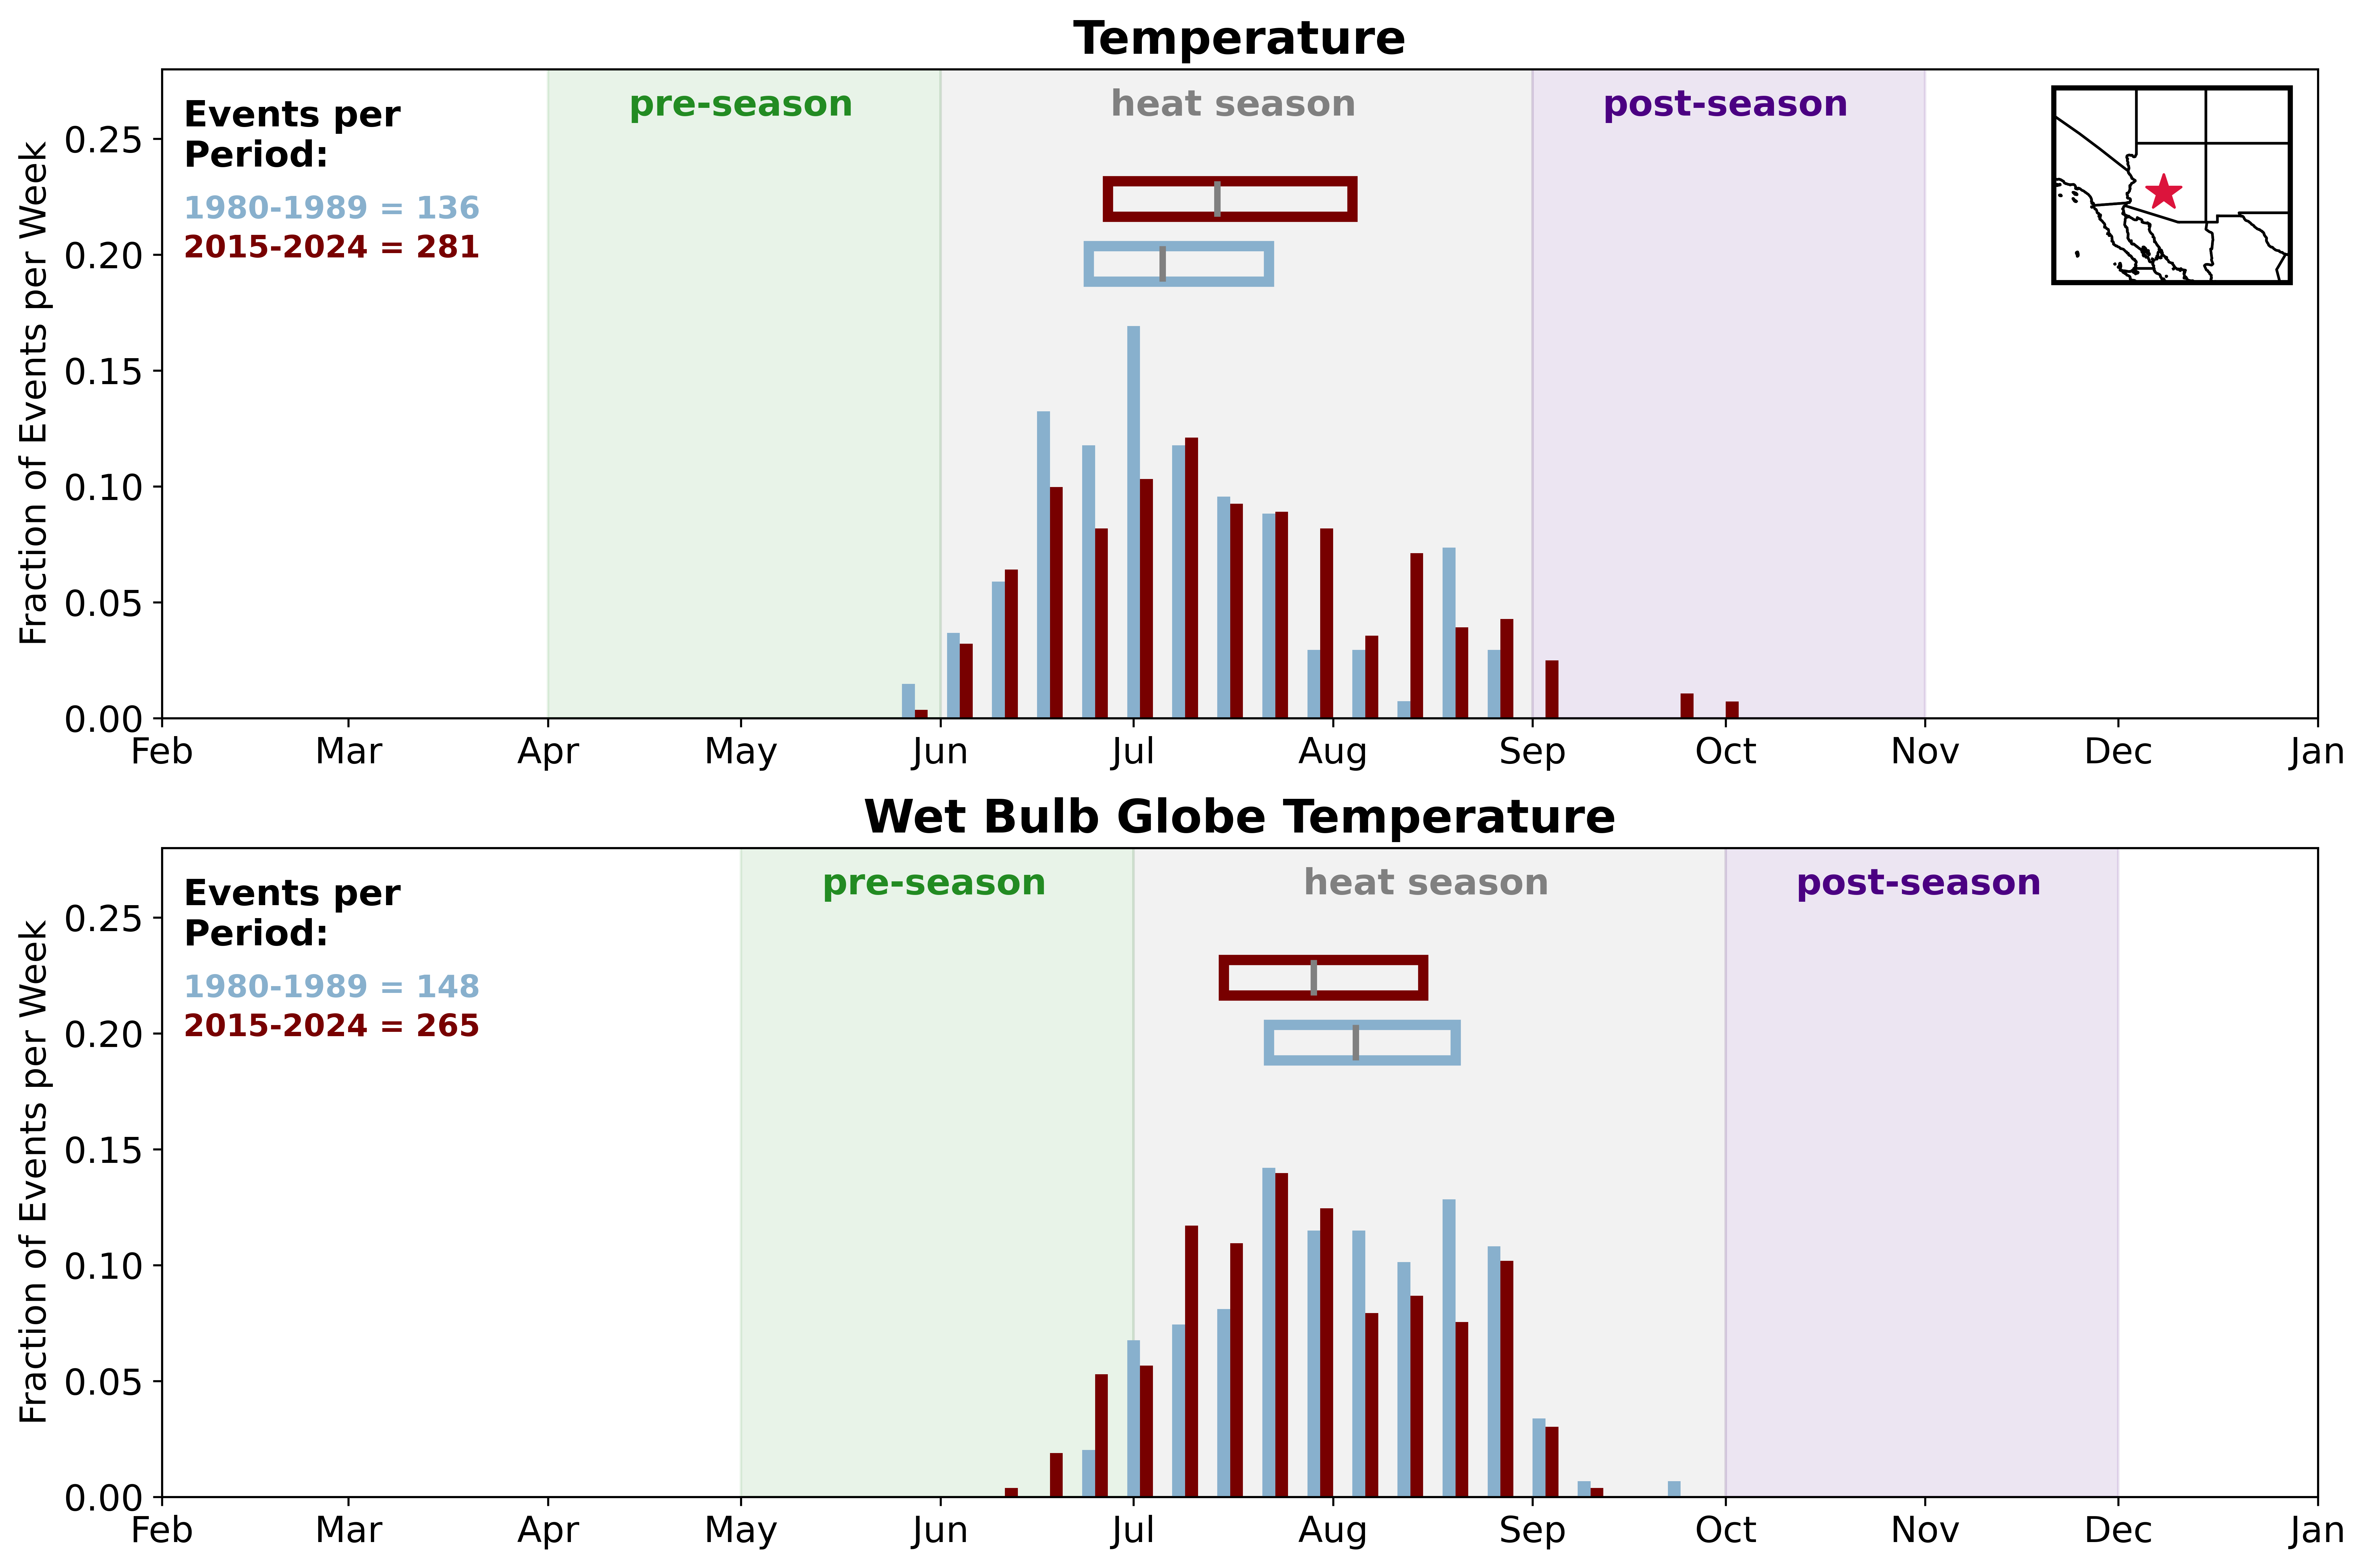

In [27]:
fontsize_main = 14
plt.rcParams.update({'font.size': fontsize_main})

fig, axs = plt.subplots(2,1, figsize = (15,10), dpi = 600)

plot_distribution_figure(T95_early_weekly_frac, T95_late_weekly_frac, T95_early_gc, T95_late_gc, axs = axs[0], event = 'T',yaxis = 'frac')

plot_distribution_figure(WBGT95_early_weekly_frac, WBGT95_late_weekly_frac, WBGT95_early_gc,WBGT95_late_gc, axs = axs[1], event = 'WBGT',yaxis = 'frac')

axs[0].set_title('Temperature', fontsize = 18, fontweight = 'bold')

axs[1].set_title('Wet Bulb Globe Temperature', fontsize = 18, fontweight = 'bold')

# Add Phoenix map inset to upper right corner

location = 'PHOENIX'
lat = 33.4483
lon = -112.0725

size = .3 # Figure Standardized coordinates (0~1)

l, b, w, h = axs[0].get_position().bounds

iax = plt.axes([l, b, size*w, size*h], projection=ccrs.PlateCarree(), label='2')

extent=[-120,-103,27,41]
iax.set_extent(extent, crs=ccrs.PlateCarree())

# Plot coastlines and states given cartopy not working
for shape in coastlines.shapeRecords():
    x = [i[0] for i in shape.shape.points[:]]
    y = [i[1] for i in shape.shape.points[:]]
    iax.plot(x,y, color = 'k', linewidth = 1)

# Max number of states/boundaries = 4595
for k in range(1,4596,1):
    shape = states.shape(k) # whichever shape
    points = np.array(shape.points)

    intervals = list(shape.parts) + [len(shape.points)]
    
    for (m, n) in zip(intervals[:-1], intervals[1:]):
        iax.plot(*zip(*points[m:n]), color = 'k', linewidth = 1)

iax.scatter(lon, lat, s = 200, marker = '*', color = 'crimson')

p1 = axs[0].get_position()
p2 = iax.get_position()

iax.set_position([p1.x1-p2.width - 0.01, p1.y1-p2.height - 0.01, p2.width, p2.height])

plt.setp(iax.spines.values(), lw=2, color='k');

# Calculations for paper text

In [64]:
# Plot both together

def calc_frac_season(data, event):
    
    if event == 'T':
        mid_month_global = mid_month_T_ds
        peak_period = peak_period_T95_gc
        early_period_shifted = T95_early_period_shifted
        late_period_shifted = T95_late_period_shifted
        early_total = T95_early_total
        late_total = T95_late_total
        early_gc = T95_early_gc
    elif event == 'WBGT':
        mid_month_global = mid_month_WBGT_ds
        peak_period = peak_period_WBGT95_gc
        early_period_shifted = WBGT95_early_period_shifted
        late_period_shifted = WBGT95_late_period_shifted
        early_total = WBGT95_early_total
        late_total = WBGT95_late_total
        early_gc = WBGT95_early_gc     
    
    # Plot shaded sections for heat season and shoulder seasons
    mid_month = int(mid_month_global.sel(lat = lat, lon = lon, method = 'nearest').values)
    
    # Find heat season months
    if mid_month == 1:
        heat_season = [12,1,2]
    elif mid_month == 12:
        heat_season = [11,12,1]
    else:
        heat_season = [mid_month-1,mid_month,mid_month+1]
    
    # Outside months
    before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
    after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]
    
    # Adjust if this gives negative numbers
    before_season = [x if x > 0  else (x+12) for x in before_season_temp]
    
    after_season = [x if x <= 12 else (x-12) for x in after_season_temp]
    
    heat_season_start_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == min(heat_season))).time.dt.dayofyear[0])
    heat_season_end_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == max(heat_season))).time.dt.dayofyear[-1])
    
    before_season_start_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == min(before_season))).time.dt.dayofyear[0])
    before_season_end_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == max(before_season))).time.dt.dayofyear[-1])
    
    after_season_start_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == min(after_season))).time.dt.dayofyear[0])
    after_season_end_DOY = int(early_gc.sel(time = (early_gc.time.dt.year == 1980) & (early_gc.time.dt.month == max(after_season))).time.dt.dayofyear[-1])
    
    heat_season_start_DOY_shifted = shift_DOY(heat_season_start_DOY - int(peak_period), 366, 183)
    heat_season_end_DOY_shifted = shift_DOY(heat_season_end_DOY - int(peak_period), 366, 183)
    
    before_season_start_DOY_shifted = shift_DOY(before_season_start_DOY - int(peak_period), 366, 183)
    before_season_end_DOY_shifted = shift_DOY(before_season_end_DOY - int(peak_period), 366, 183)
    
    after_season_start_DOY_shifted = shift_DOY(after_season_start_DOY - int(peak_period), 366, 183)
    after_season_end_DOY_shifted = shift_DOY(after_season_end_DOY - int(peak_period), 366, 183)
    
    preseason_extremes = sum(data[(np.array(early_period_shifted) >= before_season_start_DOY_shifted) & (np.array(early_period_shifted) <= before_season_end_DOY_shifted)])
    heatseason_extremes = sum(data[(np.array(early_period_shifted) >= heat_season_start_DOY_shifted) & (np.array(early_period_shifted) <= heat_season_end_DOY_shifted)])
    postseason_extremes = sum(data[(np.array(early_period_shifted) >= after_season_start_DOY_shifted) & (np.array(early_period_shifted) <= after_season_end_DOY_shifted)])
    
    print(f"{preseason_extremes.values:.2f} in preseason")
    print(f"{heatseason_extremes.values:.2f} in heat season")
    print(f"{postseason_extremes.values:.2f} in postseason")

In [78]:
calc_frac_season(WBGT95_late_weekly.groupby('time.dayofyear').sum(), event = 'WBGT')

20.00 in preseason
245.00 in heat season
0.00 in postseason


In [83]:
# Plot both together

def calc_median_iqr_shift(box_early_data, box_late_data, event):

    if event == 'T':
        mid_month_global = mid_month_T_ds
        peak_period = peak_period_T95_gc
        early_period_shifted = T95_early_period_shifted
        late_period_shifted = T95_late_period_shifted
        early_total = T95_early_total
        late_total = T95_late_total
        early_gc = T95_early_gc
    elif event == 'WBGT':
        mid_month_global = mid_month_WBGT_ds
        peak_period = peak_period_WBGT95_gc
        early_period_shifted = WBGT95_early_period_shifted
        late_period_shifted = WBGT95_late_period_shifted
        early_total = WBGT95_early_total
        late_total = WBGT95_late_total
        early_gc = WBGT95_early_gc     
    
    # At each location, record the week when each extreme event happened
    early_counts = box_early_data.where(box_early_data > 0, drop = True).time.dt.dayofyear
    late_counts = box_late_data.where(box_late_data > 0, drop = True).time.dt.dayofyear
    
    early_period = early_counts
    late_period = late_counts
    
    # Use highest frequency day to shift
    
    early_period_temp = np.array([x - int(peak_period) for x in early_period.values]) # or mid_month_T95_gc, mid_month_WBGT95_gc
    late_period_temp = np.array([x - int(peak_period) for x in late_period.values])
    
    early_period_shifted = [
        (x-shift) if x > mid else
        (x+shift) if x < -1*mid else
        x
        for x in early_period_temp
    ]
    
    late_period_shifted = [
        (x-shift) if x > mid else
        (x+shift) if x < -1*mid else
        x
        for x in late_period_temp
    ]

    early_median = np.median(early_period_shifted)
    late_median = np.median(late_period_shifted)
    median_change = late_median-early_median

    early_iqr = np.percentile(early_period_shifted, 75) - np.percentile(early_period_shifted, 25)
    late_iqr = np.percentile(late_period_shifted, 75) - np.percentile(late_period_shifted, 25)
    iqr_change = late_iqr-early_iqr

    print(f"early period median: {early_median:.1f}")
    print(f"late period median: {late_median:.1f}")
    print(f"median change: {median_change:.1f}")

    print(f"early period iqr: {early_iqr:.1f}")
    print(f"late period iqr: {late_iqr:.1f}")
    print(f"iwr change: {iqr_change:.1f}")

In [84]:
calc_median_iqr_shift(WBGT95_early_gc, WBGT95_late_gc, event = 'WBGT')

early period median: 13.5
late period median: 7.0
median change: -6.5
early period iqr: 29.0
late period iqr: 31.0
iwr change: 2.0


In [86]:
# Change in fraction
T95_pre_season = 1/281 - 2/136
print(f"T95 pre-season change: {T95_pre_season:.2f}")
T95_post_season = 12/281 - 0/136
print(f"T95 post-season change: {T95_post_season:.2f}")

WBGT95_pre_season = 20/265 - 3/148
print(f"WBGT95 pre-season change: {WBGT95_pre_season:.2f}")
WBGT95_post_season = 0/245 - 0/148
print(f"WBGT95 post-season change: {WBGT95_post_season:.2f}")

T95 pre-season change: -0.01
T95 post-season change: 0.04
WBGT95 pre-season change: 0.06
WBGT95 post-season change: 0.00


# Attribution example plot

In [7]:
# Find mean daily maximum temperatures at the gridcell
# Temperature data
Tmax_dir = '/discover/nobackup/civanovi/data/MERRA2/2mtas_daily_maximum_global/annual_files/*.nc'
global_Tmax_data = xr.open_mfdataset(Tmax_dir, parallel = True, combine = 'by_coords')

location = 'PHOENIX'
lat = 33.4483
lon = -112.0725

# Select just gridcell data
city_Tmax = global_Tmax_data.sel(lat = lat, lon = lon, method ='nearest').T2M

In [12]:
monthly_mean_T = city_Tmax.groupby('time.month').mean()

AttributeError: module 'matplotlib.pyplot' has no attribute 'xticklabels'

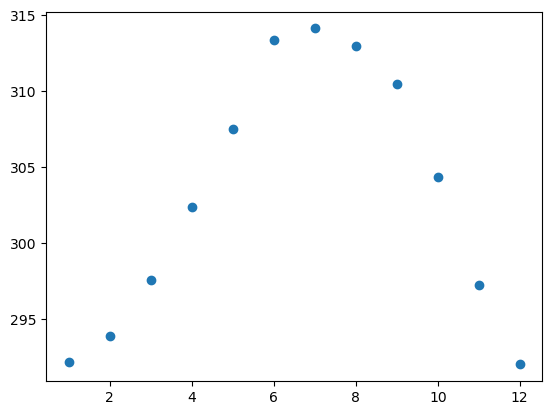

In [14]:
plt.scatter(monthly_mean_T.month, monthly_mean_T)
plt.xticklabels(['feb','apr','jun','aug','oct','dec'])

In [34]:
city_Tmax_early = city_Tmax.sel(time = slice('1980-01-01','1980-12-31'))
daily_mean_Tmax_city = city_Tmax_early.groupby('time.dayofyear').mean()

In [35]:
# Find annual mean Tmax during early and late periods, calculate temperature delta

# Select early and late periods
period_names = ['Early Period: 1980-1989','Late Period: 2015-2024']
early_period = ['1980-01-01','1989-12-31']
late_period = ['2015-01-01','2024-12-31']

city_Tmax_late = city_Tmax.sel(time = slice(late_period[0],late_period[1]))

Tmax_delta = city_Tmax_late.mean(dim = 'time') - city_Tmax_early.mean(dim = 'time')

# Add to early time period
city_Tmax_early_synth = city_Tmax_early + Tmax_delta

In [36]:
save_dir = '/discover/nobackup/civanovi/data/MERRA2/processed_data/npp_project2/'

daily_mean_Tmax_city = xr.open_dataarray(save_dir + 'daily_Tmax_phoenix_gridcell_1980.nc')
daily_mean_city_Tmax_early_synth = xr.open_dataarray(save_dir + 'synthetic_daily_Tmax_phoenix_gridcell_1980_shifted_by_deltaT.nc')

In [37]:
daily_mean_Tmax_city.load();
daily_mean_city_Tmax_early_synth.load();

In [38]:
peak_period = peak_period_T95_gc

In [39]:
# Make into dataframe so that avoid indexing order issue
d_1980 = {'dayofyear': [shift_DOY(x - int(peak_period), 366, 183) for x in city_Tmax_early.time.dt.dayofyear.values],
     'temperature': city_Tmax_early - 273.15}
df_1980 = pd.DataFrame(data=d_1980)
df_1980_sorted = df_1980.sort_values('dayofyear')

d_synthetic = {'dayofyear': [shift_DOY(x - int(peak_period), 366, 183) for x in city_Tmax_early_synth.time.dt.dayofyear.values],
     'temperature': city_Tmax_early_synth - 273.15}
df_synthetic = pd.DataFrame(data=d_synthetic)
df_synthetic_sorted = df_synthetic.sort_values('dayofyear')

[Text(181, 0, 'Jan'),
 Text(-154, 0, 'Feb'),
 Text(-125, 0, 'Mar'),
 Text(-94, 0, 'Apr'),
 Text(-64, 0, 'May'),
 Text(-33, 0, 'Jun'),
 Text(-3, 0, 'Jul'),
 Text(28, 0, 'Aug'),
 Text(59, 0, 'Sep'),
 Text(89, 0, 'Oct'),
 Text(120, 0, 'Nov'),
 Text(150, 0, 'Dec')]

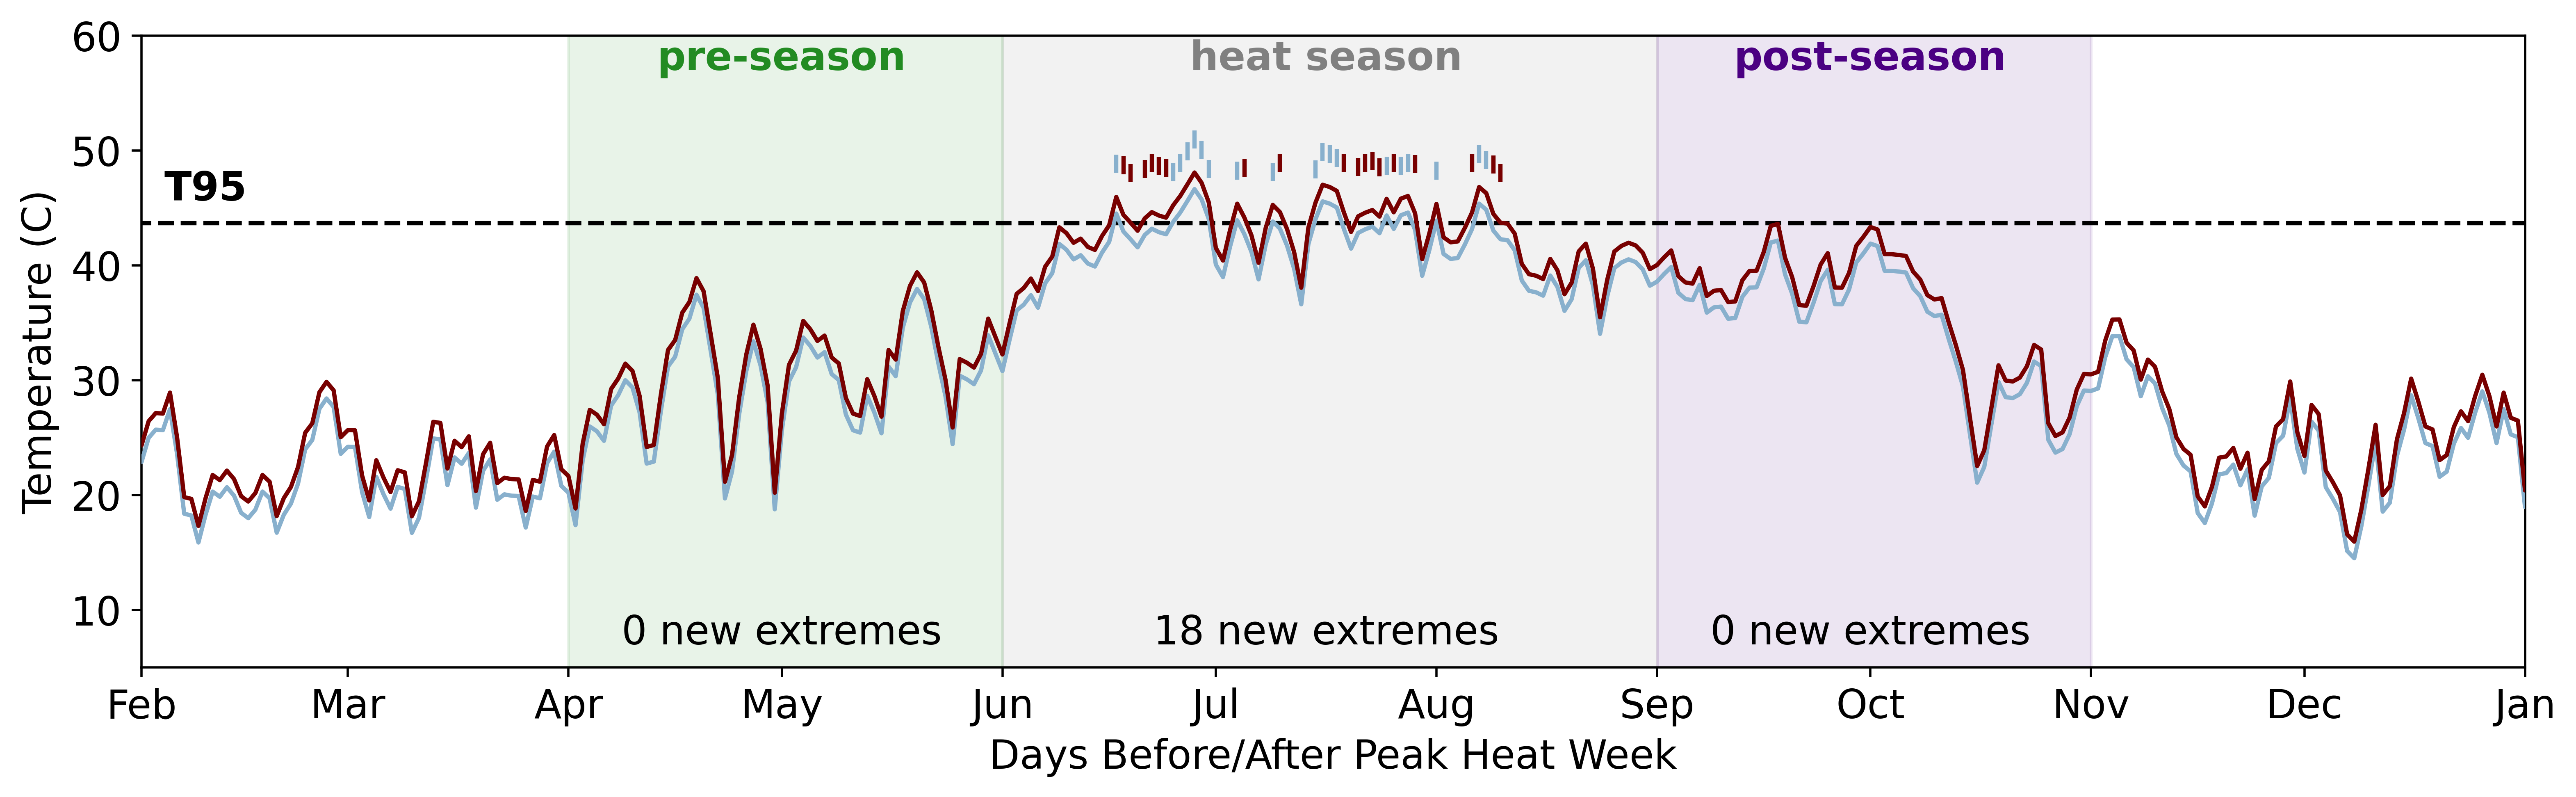

In [40]:
early_color = '#88b0cd'
late_color = '#780000'

shift = 366
mid = shift/2

T95 = 316.82102966308594 - 273.15

width = 2

bins = np.arange(-25.5,26.5,1)
ymax = 60

mid_month_global = mid_month_T_ds
peak_period = peak_period_T95_gc

fontsize_main = 14
plt.rcParams.update({'font.size': fontsize_main})

fig, axs = plt.subplots(1, figsize = (15,4), dpi = 500)

early_plot = axs.plot(df_1980_sorted.dayofyear, df_1980_sorted.temperature, color = early_color, label = 'Early Period 1980-1989', zorder = 10)
late_plot = axs.plot(df_synthetic_sorted.dayofyear, df_synthetic_sorted.temperature + 0.7, color = late_color, label = 'Late Period 2015-2024', zorder = 10)

# Plot extremes on top
extremes_1980 = df_1980_sorted[df_1980_sorted.temperature > T95]
early_extremes_plot = axs.scatter(extremes_1980.dayofyear, extremes_1980.temperature + 3 + 1.33, s = 40, color = early_color, marker = '|', zorder = 11)

extremes_synth = df_synthetic_sorted[df_synthetic_sorted.temperature + 0.7 > T95]
extremes_synth_new = extremes_synth[~extremes_synth['dayofyear'].isin(extremes_1980['dayofyear'])]
new_synth_extremes_plot = axs.scatter(extremes_synth_new.dayofyear, extremes_synth_new.temperature + 5, s = 40, color = late_color, marker = '|', zorder = 11)

# Plot horizontal line for T95
axs.hlines(T95, xmin = -183 , xmax = 183, color = 'k', linestyle = 'dashed')

axs.set_ylabel('Temperature (C)')
axs.set_xlabel('Days Before/After Peak Heat Week')

axs.set_ylim([5,ymax])
axs.set_xlim([-1*mid + 40 ,mid -40])

# Plot shaded sections for heat season and shoulder seasons

mid_month = int(mid_month_global.sel(lat = lat, lon = lon, method = 'nearest').values)

# Find heat season months
if mid_month == 1:
    heat_season = [12,1,2]
elif mid_month == 12:
    heat_season = [11,12,1]
else:
    heat_season = [mid_month-1,mid_month,mid_month+1]

# Outside months
before_season_temp = [heat_season[0] - 2,heat_season[0] - 1]
after_season_temp = [heat_season[2] + 1,heat_season[2] + 2]

# Adjust if this gives negative numbers
before_season = [x if x > 0  else (x+12) for x in before_season_temp]

after_season = [x if x <= 12 else (x-12) for x in after_season_temp]

heat_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(heat_season))).time.dt.dayofyear[0])
heat_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(heat_season))).time.dt.dayofyear[-1])

before_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(before_season))).time.dt.dayofyear[0])
before_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(before_season))).time.dt.dayofyear[-1])

after_season_start_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == min(after_season))).time.dt.dayofyear[0])
after_season_end_DOY = int(T95_early_gc.sel(time = (T95_early_gc.time.dt.year == 1980) & (T95_early_gc.time.dt.month == max(after_season))).time.dt.dayofyear[-1])

heat_season_start_DOY_shifted = shift_DOY(heat_season_start_DOY - int(peak_period), 366, 183)
heat_season_end_DOY_shifted = shift_DOY(heat_season_end_DOY - int(peak_period), 366, 183)

before_season_start_DOY_shifted = shift_DOY(before_season_start_DOY - int(peak_period), 366, 183)
before_season_end_DOY_shifted = shift_DOY(before_season_end_DOY - int(peak_period), 366, 183)

after_season_start_DOY_shifted = shift_DOY(after_season_start_DOY - int(peak_period), 366, 183)
after_season_end_DOY_shifted = shift_DOY(after_season_end_DOY - int(peak_period), 366, 183)
    
axs.axvspan(heat_season_start_DOY_shifted, heat_season_end_DOY_shifted+1, color='grey', alpha = 0.1, zorder = 0)
axs.text((heat_season_start_DOY_shifted + heat_season_end_DOY_shifted)/2, ymax - 3, "heat season", color = 'grey', fontweight = 'bold', ha = 'center')

axs.axvspan(before_season_start_DOY_shifted, before_season_end_DOY_shifted+1, color='forestgreen', alpha = 0.1, zorder = 0)
axs.text((before_season_start_DOY_shifted + before_season_end_DOY_shifted)/2, ymax -3, "pre-season", color = 'forestgreen', fontweight = 'bold', ha = 'center')

axs.axvspan(after_season_start_DOY_shifted, after_season_end_DOY_shifted+1, color='indigo', alpha = 0.1, zorder = 0)
axs.text((after_season_start_DOY_shifted + after_season_end_DOY_shifted)/2, ymax - 3, "post-season", color = 'indigo',  fontweight = 'bold', ha = 'center')

axs.text(-145, T95 + 2, "T95", color = 'k',  fontweight = 'bold', ha = 'center')

# Find number of extremes in each season

preseason_extremes = len(extremes_1980[(extremes_1980.dayofyear >= before_season_start_DOY_shifted) & (extremes_1980.dayofyear <= before_season_end_DOY_shifted)])
heatseason_extremes = len(extremes_1980[(extremes_1980.dayofyear >= heat_season_start_DOY_shifted) & (extremes_1980.dayofyear <= heat_season_end_DOY_shifted)])
postseason_extremes = len(extremes_1980[(extremes_1980.dayofyear >= after_season_start_DOY_shifted) & (extremes_1980.dayofyear <= after_season_end_DOY_shifted)])
'''
axs.text((before_season_start_DOY_shifted + before_season_end_DOY_shifted)/2, 7,
         f"{int(preseason_extremes):.0f} extremes", color = 'k', ha = 'center')

axs.text((heat_season_start_DOY_shifted + heat_season_end_DOY_shifted)/2, 7,
         f"{int(heatseason_extremes):.0f} extremes", color = 'k', ha = 'center')

axs.text((after_season_start_DOY_shifted + after_season_end_DOY_shifted)/2, 7,
         f"{int(postseason_extremes):.0f} extremes", color = 'k', ha = 'center')
'''
new_preseason_extremes = len(extremes_synth_new[(extremes_synth_new.dayofyear >= before_season_start_DOY_shifted) & (extremes_synth_new.dayofyear <= before_season_end_DOY_shifted)])
new_heatseason_extremes = len(extremes_synth_new[(extremes_synth_new.dayofyear >= heat_season_start_DOY_shifted) & (extremes_synth_new.dayofyear <= heat_season_end_DOY_shifted)])
new_postseason_extremes = len(extremes_synth_new[(extremes_synth_new.dayofyear >= after_season_start_DOY_shifted) & (extremes_synth_new.dayofyear <= after_season_end_DOY_shifted)])

axs.text((before_season_start_DOY_shifted + before_season_end_DOY_shifted)/2, 7,
         f"{int(new_preseason_extremes):.0f} new extremes", color = 'k', ha = 'center')

axs.text((heat_season_start_DOY_shifted + heat_season_end_DOY_shifted)/2, 7,
         f"{int(new_heatseason_extremes):.0f} new extremes", color = 'k', ha = 'center')

axs.text((after_season_start_DOY_shifted + after_season_end_DOY_shifted)/2, 7,
         f"{int(new_postseason_extremes):.0f} new extremes", color = 'k', ha = 'center')

# Update xticks to months
ticks_unshifted = [1,32,61,92,122,153,183,214,245,275,306,336]
ticks_shifted = [shift_DOY(x - int(peak_period), 366, 183) for x in ticks_unshifted]
tick_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

axs.set_xticks(ticks_shifted)
axs.set_xticklabels(tick_labels)

# Generate synthetic distribution

In [3]:
from scipy.stats import gengamma

In [12]:
a1, c1 = 4.42, -3.12
a2, c2 = 6, -3.12

mean, var, skew, kurt = gengamma.stats(a1, c1, moments='mvsk')

In [13]:
x = np.linspace(gengamma.ppf(0.01, a1, c1),
                gengamma.ppf(0.99, a1, c1), 100)

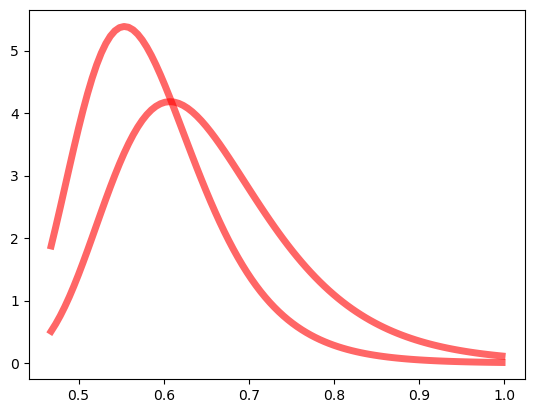

In [15]:
plt.plot(x, gengamma.pdf(x, a1, c1),
       'r-', lw=5, alpha=0.6, label='gengamma pdf')

plt.plot(x, gengamma.pdf(x, a2, c2),
       'r-', lw=5, alpha=0.6, label='gengamma pdf')

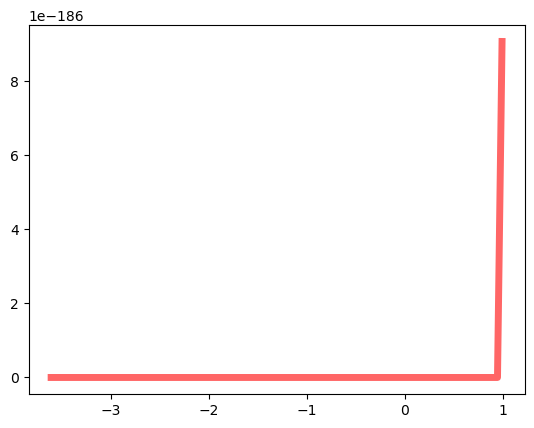

In [22]:
distribution = scipy.stats.gengamma(100, 70, loc=50, scale=10)

plt.plot(x, gengamma.pdf(x, 100, 70),
       'r-', lw=5, alpha=0.6, label='gengamma pdf')

In [18]:
mu, sigma = 0, 0.1 # mean and standard deviation
s = np.random.normal(mu, sigma, 1000)

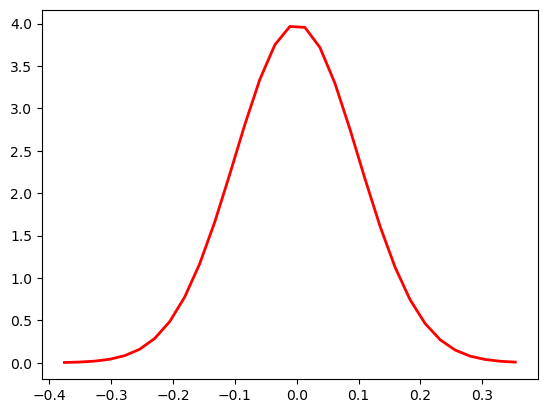

In [20]:
count, bins, ignored = plt.hist(s, 30, density=True)

plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) *
               np.exp( - (bins - mu)**2 / (2 * sigma**2) ),
         linewidth=2, color='r')
plt.show()

In [29]:
import numpy as np
from scipy.stats import pearson3

# Define desired parameters
mean1 = 0
std_dev1 = 2  # Standard deviation (related to variance)
skewness1 = 0.5

mean2 = 0
std_dev2 = 5  # Standard deviation (related to variance)
skewness2 = 0.2

# Generate random variates
size = 10000
random_data1 = pearson3.rvs(skew=skewness1, loc=mean1, scale=std_dev1, size=size)
random_data2 = pearson3.rvs(skew=skewness2, loc=mean2, scale=std_dev2, size=size)

In [30]:
# Verify the moments of the generated data
#print(f"Generated data mean: {np.mean(random_data):.2f}")
##print(f"Generated data standard deviation: {np.std(random_data):.2f}")
##print(f"Generated data skewness: {pearson3.stats(skew=skewness, moments='s', loc=mean, scale=std_dev):.2f}")
print(f"Generated data kurtosis1 (excess): {pearson3.stats(skew=skewness1, moments='k', loc=mean1, scale=std_dev1):.2f}")
print(f"Generated data kurtosis2 (excess): {pearson3.stats(skew=skewness2, moments='k', loc=mean2, scale=std_dev2):.2f}")

print(f"Generated data kurtosis1 (excess): {stats.kurtosis(random_data1, fisher = False)-3:.2f}")
print(f"Generated data kurtosis2 (excess): {stats.kurtosis(random_data2, fisher = False)-3:.2f}")

Generated data kurtosis1 (excess): 0.38
Generated data kurtosis2 (excess): 0.06
Generated data kurtosis1 (excess): 0.32
Generated data kurtosis2 (excess): 0.15


In [31]:
xmin = -15
xmax = 25

x = np.linspace(xmin,xmax,100)
pdf_values1 = pearson3.pdf(x, skewness1, loc=mean1, scale=std_dev1)
pdf_values2 = pearson3.pdf(x, skewness2, loc=mean2, scale=std_dev2)

(-15.0, 25.0)

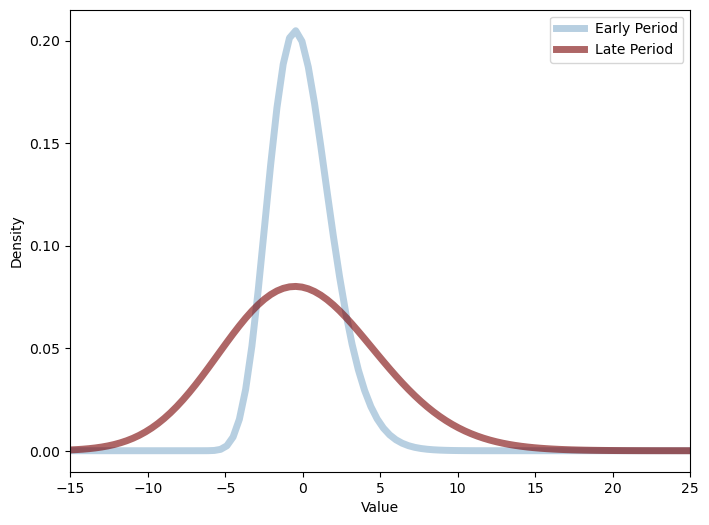

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, pdf_values1, color = '#88b0cd', lw=5, alpha=0.6, label='Early Period')
ax.plot(x, pdf_values2, color = '#780000', lw=5, alpha=0.6, label='Late Period')
#ax.hist(random_data, density=True, bins='auto', histtype='stepfilled', alpha=0.2, label='Sample data histogram')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend(loc='best', frameon=True)
ax.set_xlim([xmin,xmax])